In [1]:
import pandas as pd
from scripts.utils import load_analysis_df, parquet_exists
from scripts.bivariate_analysis import (
    bivariate_scatter,
    correlation_heatmap,
    bivariate_boxplot,
    bivariate_bar_mean,
    bivariate_flag_comparison,
    categorical_crosstab_heatmap,
    bivariate_stacked_bar
)

In [2]:
if parquet_exists():
    df = load_analysis_df()

[OK] Loaded analysis DataFrame ← c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\data\cleaned_and_processed_data.parquet  (953 rows × 32 cols)


Correlation Heatmap  (Pearson)
  Top 5 strongest correlations:
    Price                × Price_Per_Night       r = +0.9931
    Detail_Word_Count    × Detail_Char_Count     r = +0.8225
    Price                × Bed_Count             r = +0.2649
    Price_Per_Night      × Bed_Count             r = +0.2619
    Price                × Rating                r = +0.1803


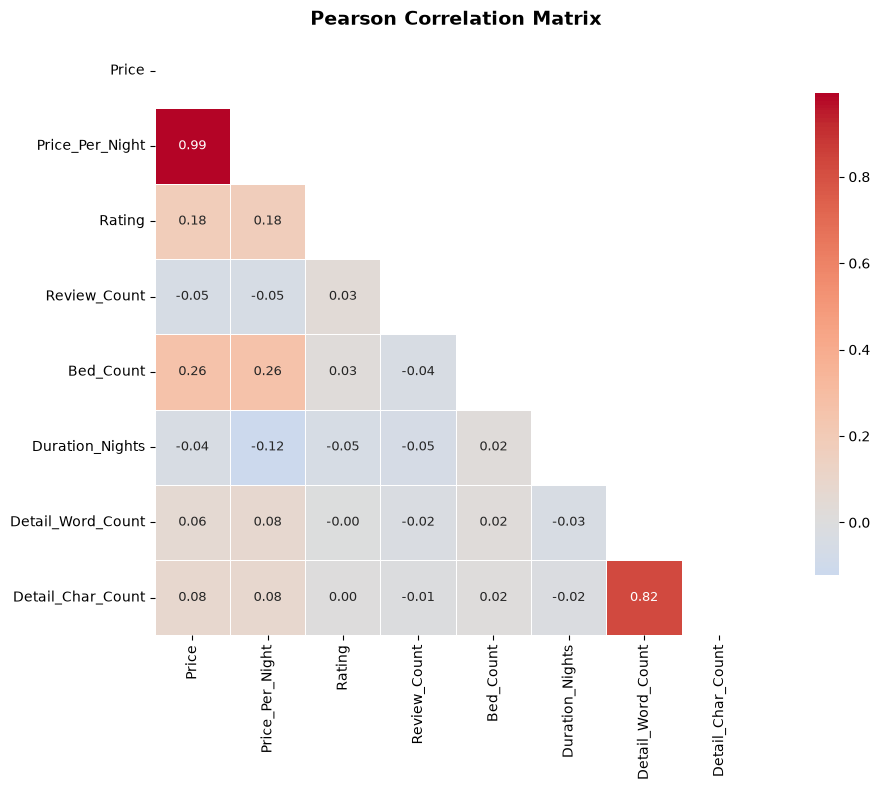

,Price,Price_Per_Night,Rating,Review_Count,Bed_Count,Duration_Nights,Detail_Word_Count,Detail_Char_Count
Price,1.000000,0.993118,0.180283,-0.051518,0.264917,-0.042458,0.063767,0.078874
Price_Per_Night,0.993118,1.000000,0.175317,-0.050439,0.261862,-0.121981,0.076044,0.078806
Rating,0.180283,0.175317,1.000000,0.034895,0.025339,-0.045299,-0.001187,0.004004
Review_Count,-0.051518,-0.050439,0.034895,1.000000,-0.038811,-0.054203,-0.021886,-0.008766
Bed_Count,0.264917,0.261862,0.025339,-0.038811,1.000000,0.018790,0.022187,0.016219
Duration_Nights,-0.042458,-0.121981,-0.045299,-0.054203,0.018790,1.000000,-0.034989,-0.018808
Detail_Word_Count,0.063767,0.076044,-0.001187,-0.021886,0.022187,-0.034989,1.000000,0.822521
Detail_Char_Count,0.078874,0.078806,0.004004,-0.008766,0.016219,-0.018808,0.822521,1.000000


In [3]:
correlation_heatmap(
    df,
    columns=[
        "Price", "Price_Per_Night", "Rating", "Review_Count",
        "Bed_Count", "Duration_Nights", "Detail_Word_Count", "Detail_Char_Count",
    ],
)

Scatter — Price vs Rating
  Non-null pairs : 931
  Pearson r      : 0.1803


c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:62: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


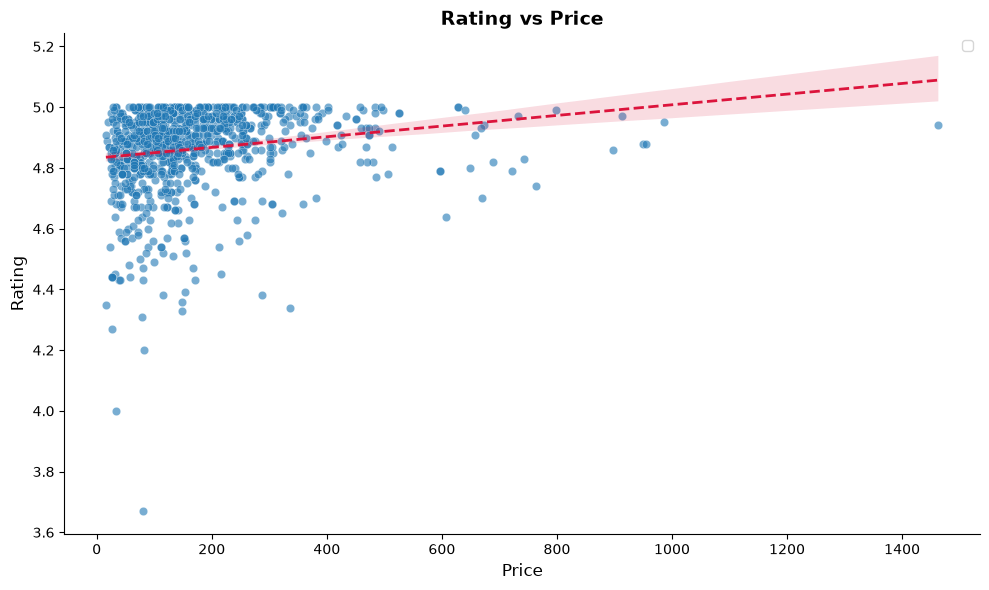

In [4]:
# Q: Do more expensive listings guarantee better guest ratings?

bivariate_scatter(df, "Price", "Rating")

Scatter — Price vs Review_Count
  Non-null pairs : 947
  Pearson r      : -0.0515


c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:62: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


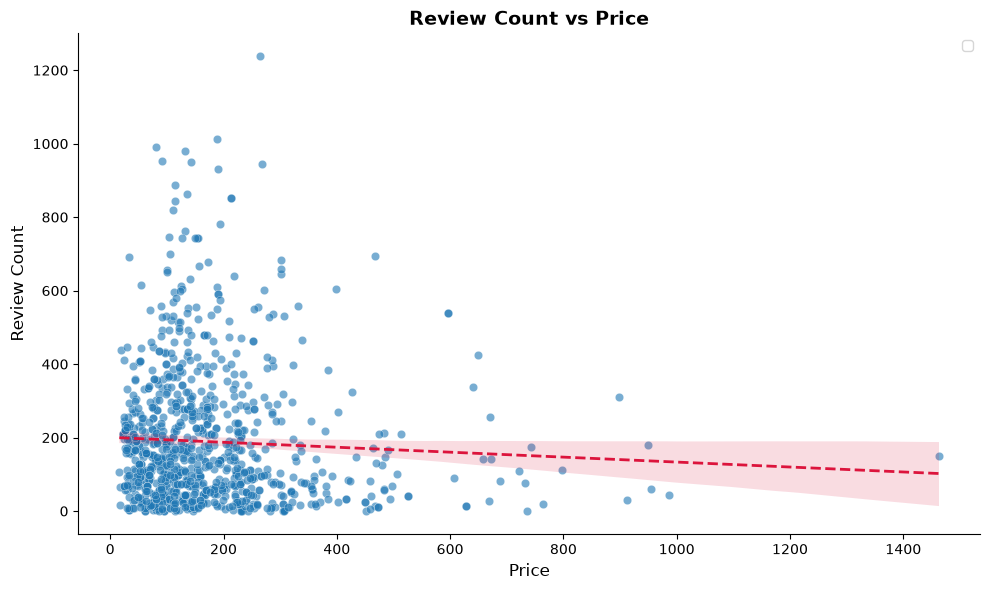

In [5]:
# Q: Are highly reviewed (popular) listings more expensive, or do budget
#    listings attract the most bookings?

bivariate_scatter(df, "Price", "Review_Count")

Scatter — Price vs Bed_Count
  Non-null pairs : 953
  Pearson r      : 0.2649


c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:62: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


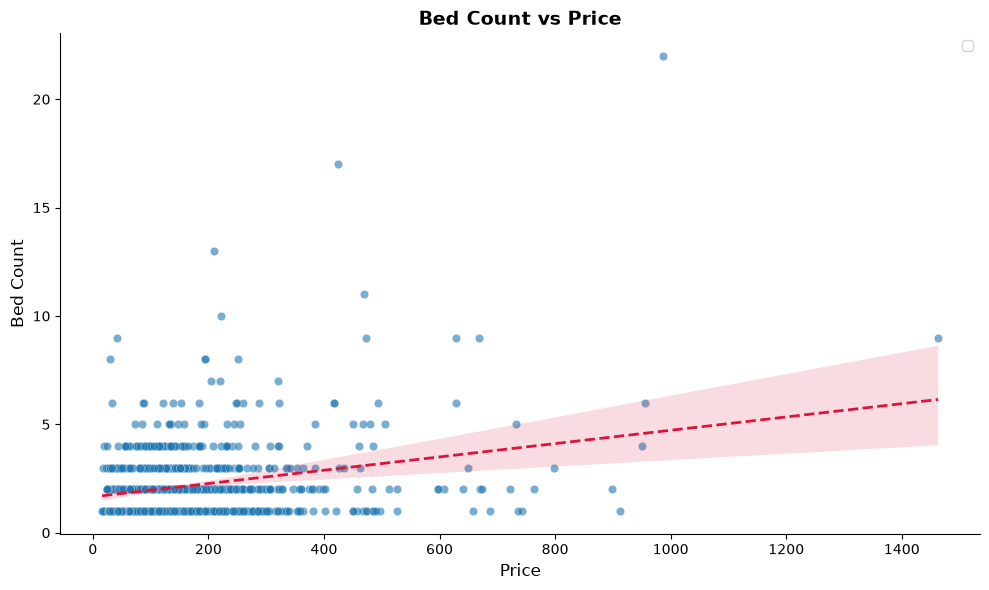

In [6]:
# Q: Does the number of beds strongly predict the listing price?

bivariate_scatter(df, "Price", "Bed_Count")

Scatter — Price_Per_Night vs Rating
  Non-null pairs : 866
  Pearson r      : 0.1753


c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:62: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


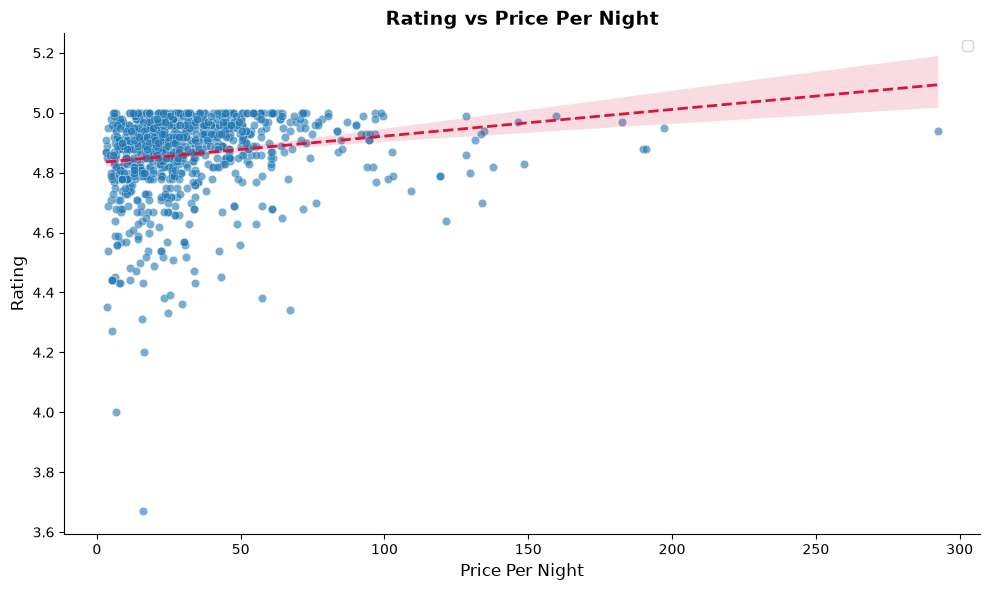

In [7]:
# Q: Is there a value-for-money pattern — do cheaper-per-night listings
#    get rated worse, or is quality independent of nightly rate?

bivariate_scatter(df, "Price_Per_Night", "Rating")

Scatter — Rating vs Review_Count
  Non-null pairs : 931
  Pearson r      : 0.0349


c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:62: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


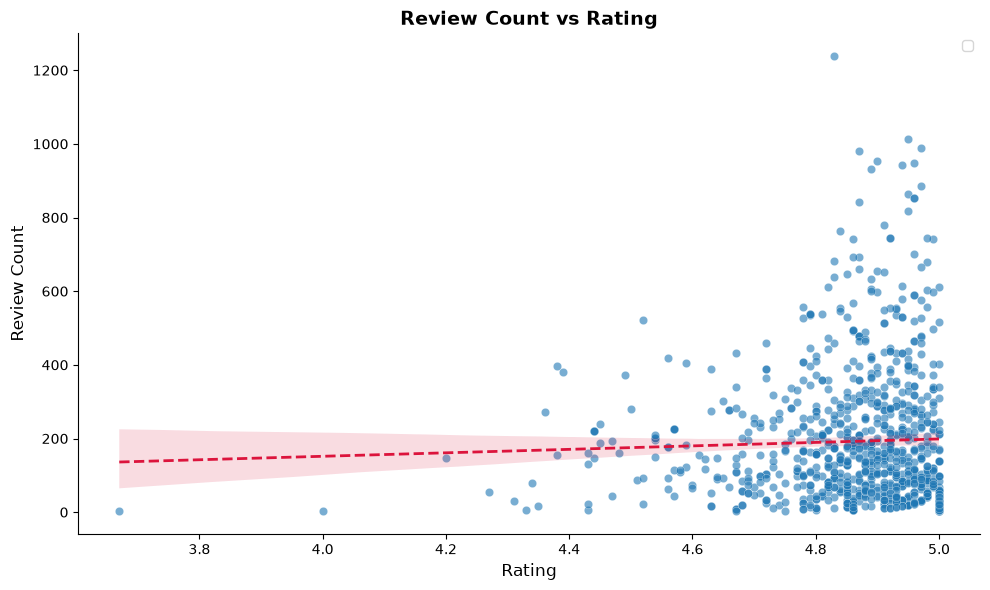

In [8]:
# Q: Do highly rated listings accumulate more reviews over time, or do
#    volume and quality move independently?

bivariate_scatter(df, "Rating", "Review_Count")


Scatter — Detail_Word_Count vs Price
  Non-null pairs : 953
  Pearson r      : 0.0638


c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:62: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


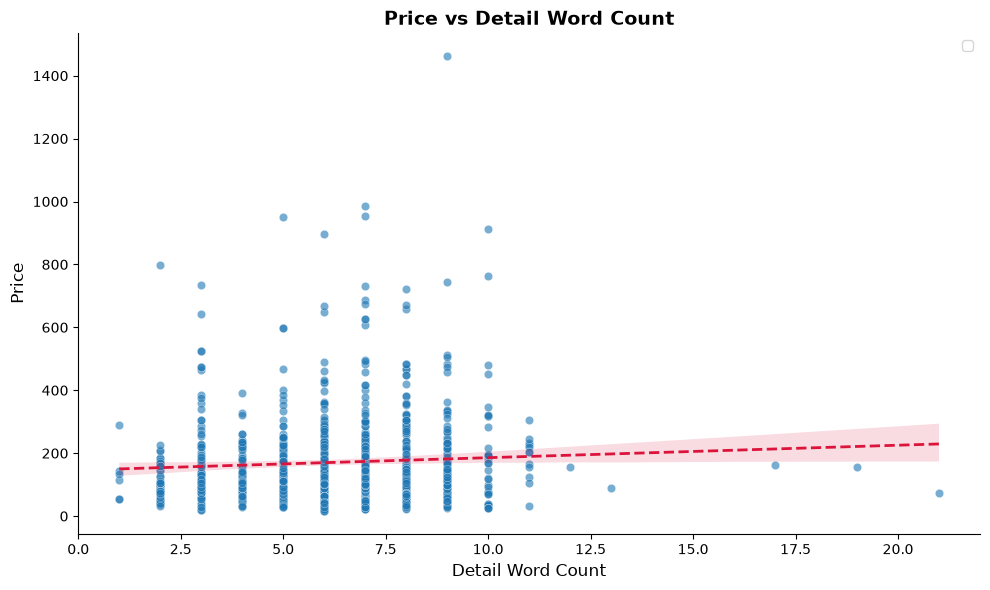

In [9]:
# Q: Do hosts who write longer, more descriptive taglines tend to charge
#    higher prices?  (Signal of professional hosts vs casual ones.)

bivariate_scatter(df, "Detail_Word_Count", "Price")

Scatter — Duration_Nights vs Price_Per_Night
  Non-null pairs : 888
  Pearson r      : -0.1220


c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:62: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
c:\Users\lenov\OneDrive\Desktop\ai-project-collection\Airbnb-Listings-Deep-Dive\Notebooks\scripts\bivariate_analysis.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


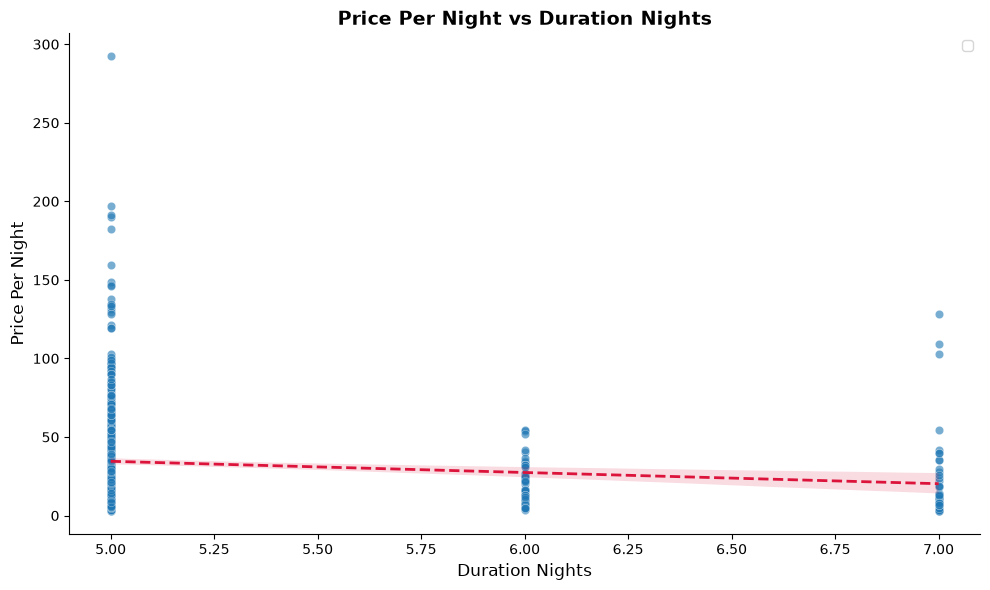

In [10]:
# Q: Do longer-stay listings offer a lower per-night rate (bulk discount
#    effect), or is duration unrelated to nightly pricing?

bivariate_scatter(df, "Duration_Nights", "Price_Per_Night")

Box Plot — Price by Theme  (top 9)
           count  median        mean         std
Theme                                           
Beach        208   162.0  211.701923  187.669067
Luxury        89   147.0  187.123596  142.321884
Historic      20   141.0  138.250000   78.608206
Nature       182   138.0  176.714286  120.442397
Adventure     30   128.5  169.000000   96.917669
General      324   116.5  154.969136  131.081376
Romantic      54   112.5  150.092593  102.356438
Family        12    82.5  103.250000   60.648203
Urban         34    77.5   90.117647   52.537874


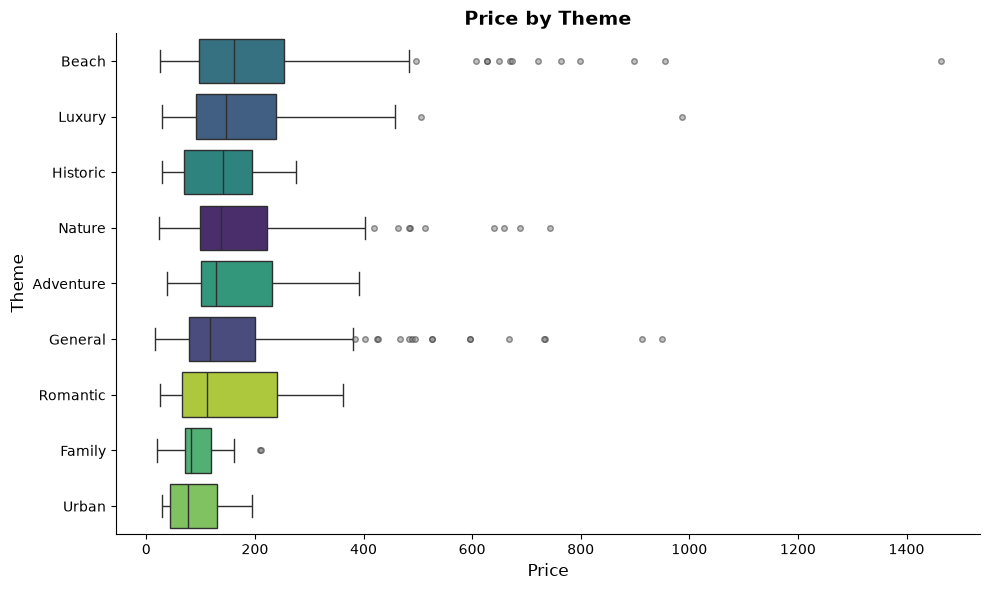

In [11]:
# Q: Which thematic category commands the highest nightly premium?

bivariate_boxplot(df, "Theme", "Price", top_n=9)

Box Plot — Rating by Theme  (top 9)
           count  median      mean       std
Theme                                       
Family        12   4.940  4.946667  0.029644
Historic      20   4.940  4.923000  0.062836
Adventure     28   4.935  4.875357  0.138577
Nature       178   4.910  4.891910  0.111232
Romantic      54   4.895  4.855741  0.174665
Urban         34   4.890  4.842647  0.148555
General      313   4.890  4.861054  0.144563
Luxury        88   4.880  4.867614  0.109691
Beach        204   4.870  4.829412  0.145106


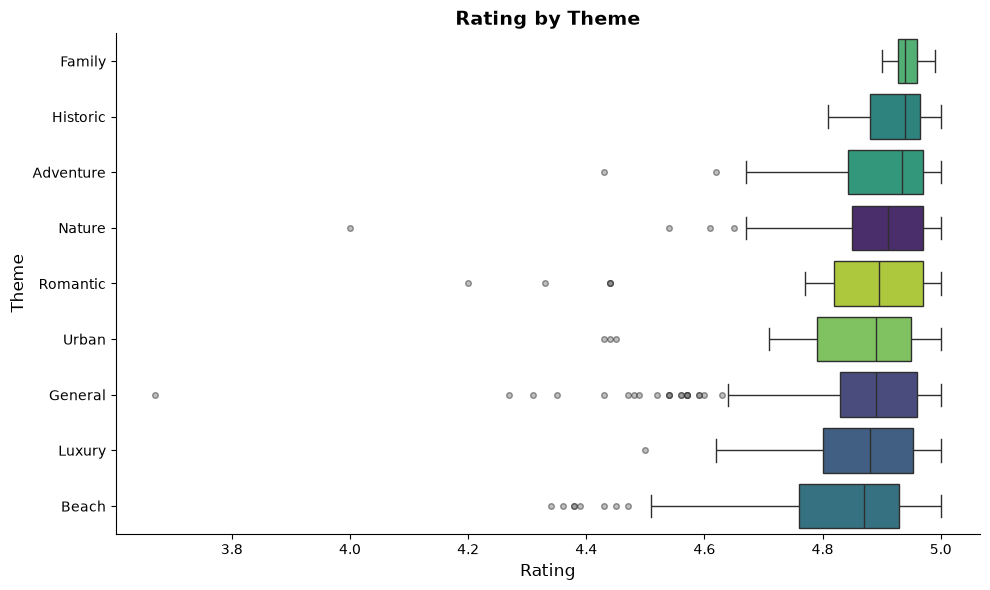

In [12]:
# Q: Are certain themes consistently rated higher by guests?

bivariate_boxplot(df, "Theme", "Rating", top_n=9)

Box Plot — Price by Property_Type  (top 10)
               count  median        mean         std
Property_Type                                       
Villa             62   219.0  287.080645  182.045328
Treehouse         37   207.0  235.486486  185.760393
Home             123   184.0  238.113821  205.446144
Cabin            116   171.0  193.310345  124.342264
Cottage           34   147.5  218.147059  161.631105
Condo             95   144.0  168.263158  145.140666
Tiny home         42   125.0  137.261905   60.799173
Guesthouse        26   104.5  119.307692   54.772818
Room              83    92.0  103.457831   73.049148
Apartment        119    90.0  122.285714   96.887681


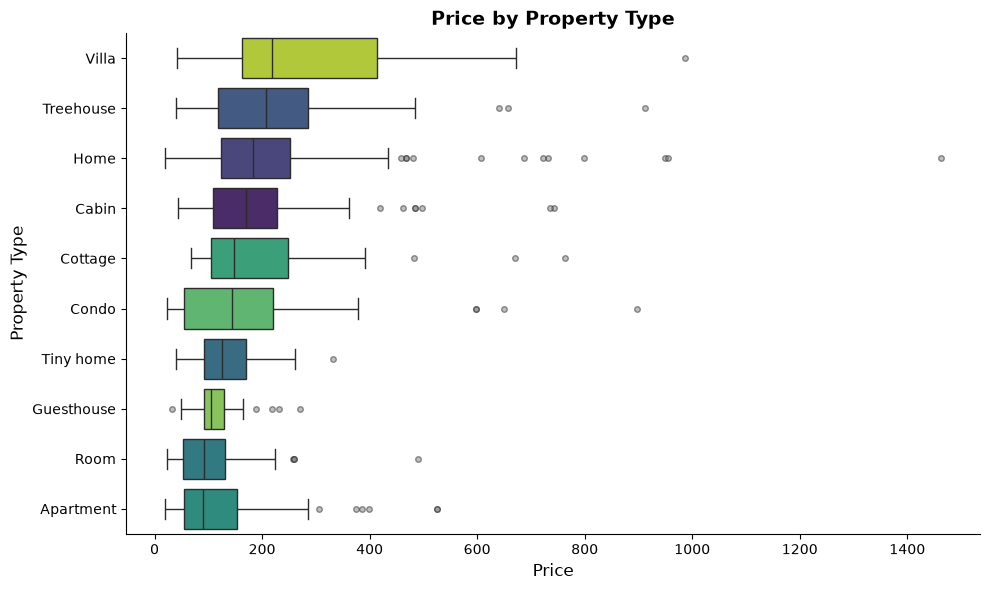

In [13]:
# Q: Which property types are the most expensive?  Are niche types
#    (Treehouse, Tiny home) priced higher than standard ones (Apartment)?

bivariate_boxplot(df, "Property_Type", "Price", top_n=10)

Box Plot — Rating by Property_Type  (top 10)
               count  median      mean       std
Property_Type                                   
Tiny home         42   4.945  4.914286  0.102532
Cabin            113   4.930  4.906195  0.094381
Villa             61   4.920  4.898852  0.099417
Cottage           33   4.920  4.908485  0.071725
Guesthouse        23   4.920  4.911304  0.067710
Room              82   4.910  4.903293  0.075098
Treehouse         34   4.910  4.893824  0.093193
Home             118   4.910  4.887034  0.107085
Condo             95   4.830  4.798000  0.152166
Apartment        116   4.820  4.779138  0.185672


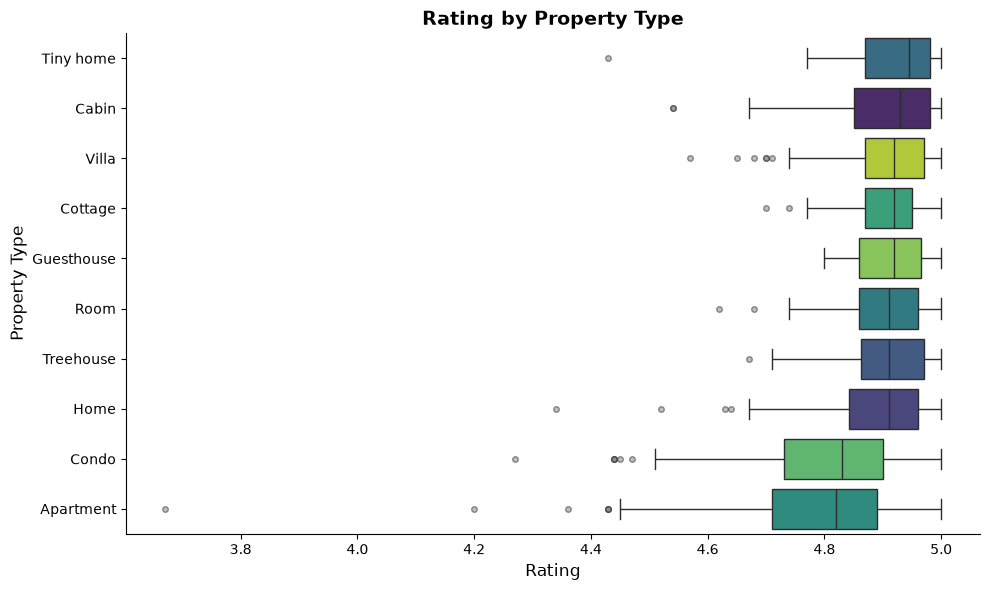

In [14]:
# Q: Which property types receive the best guest satisfaction scores?

bivariate_boxplot(df, "Property_Type", "Rating", top_n=10)

Box Plot — Price by Country  (top 10)
             count  median        mean         std
Country                                           
US             115   221.0  251.773913  186.117491
Unknown        251   176.0  208.414343  132.906658
Indonesia      110   168.5  205.381818  153.142015
Canada          44   158.0  219.318182  151.566360
UK              34   141.0  161.176471   79.539383
Italy           34    92.5  108.441176   49.890906
Mexico          40    76.5   95.350000   64.842037
Thailand        69    65.0  101.202899  125.644641
Philippines     37    62.0  150.243243  177.015914
Malaysia        26    52.5   57.500000   30.430577


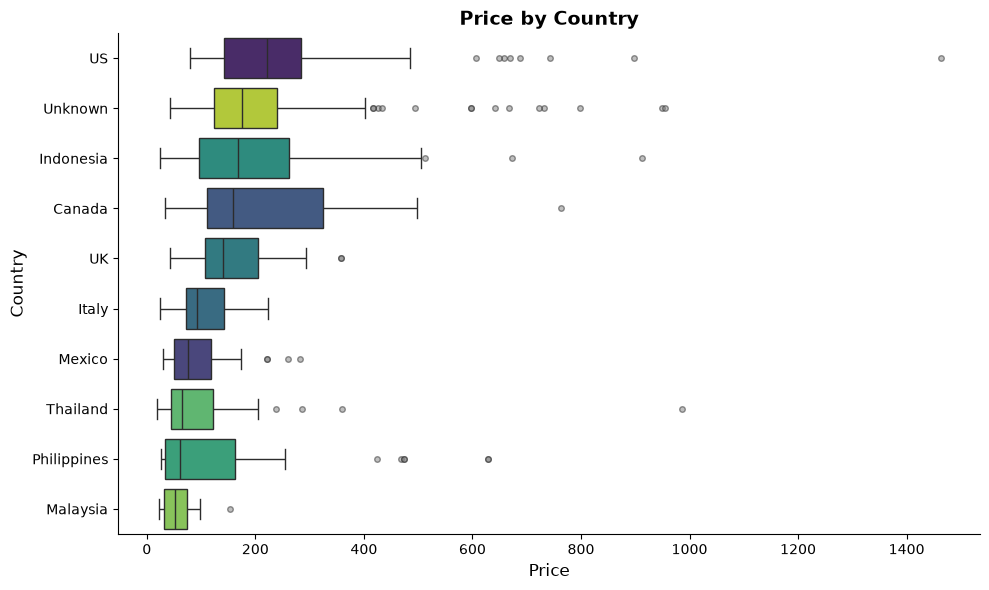

In [15]:
# Q: How do listing prices vary across the top countries?  Are Southeast
#    Asian markets (Indonesia, Thailand) significantly cheaper than the US?

bivariate_boxplot(df, "Country", "Price", top_n=10)

Box Plot — Rating by Country  (top 10)
             count  median      mean       std
Country                                       
UK              34   4.955  4.933235  0.070269
Unknown        249   4.930  4.898072  0.108707
Canada          44   4.905  4.893409  0.157583
Indonesia      109   4.890  4.863761  0.108199
Italy           33   4.880  4.857576  0.155925
Philippines     37   4.880  4.826757  0.165043
Thailand        69   4.870  4.846667  0.117206
US             109   4.870  4.849266  0.149955
Mexico          39   4.820  4.776923  0.145279
Malaysia        26   4.795  4.748462  0.179860


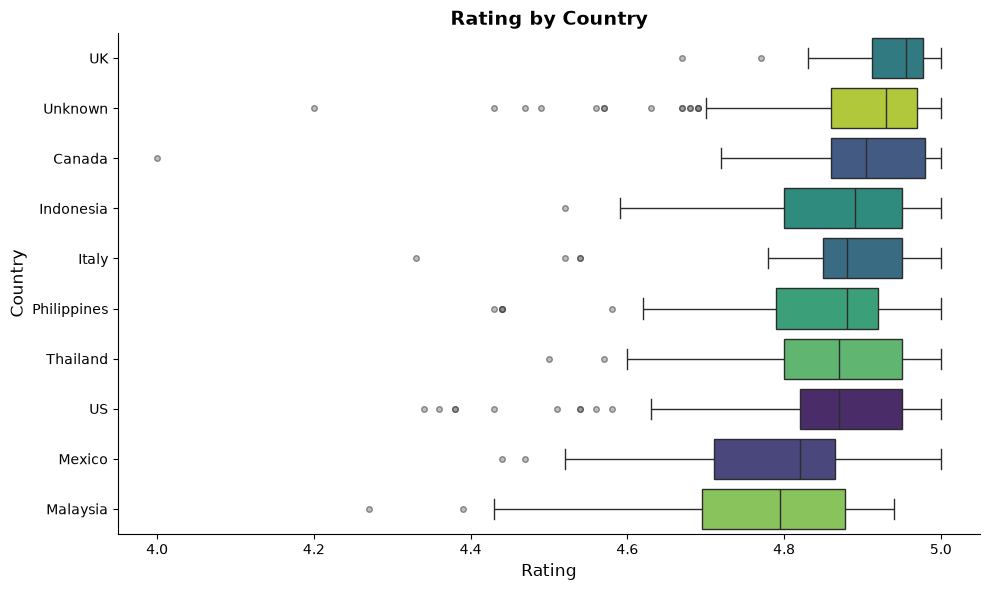

In [16]:
# Q: Do certain countries consistently produce higher-rated listings?

bivariate_boxplot(df, "Country", "Rating", top_n=10)

Box Plot — Price by Bed_Type  (top 7)
          count  median        mean         std
Bed_Type                                       
Queen       163   146.0  169.546012  123.514392
Standard    552   140.0  182.139493  153.646790
King        110   126.5  156.963636  127.698320
Double       91   111.0  152.692308  124.025507
Single       11    98.0   99.454545   54.205837
Sofa         23    84.0  112.000000   75.747787
Bunk          3    22.0   98.333333  132.213212


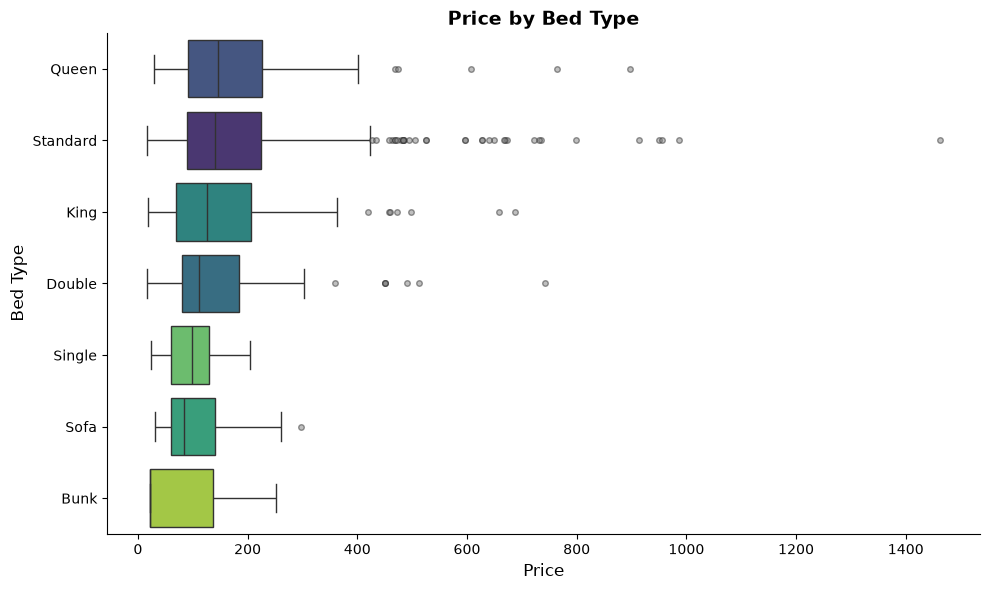

In [17]:
# Q: Do listings with King or Queen beds charge a premium over Standard?

bivariate_boxplot(df, "Bed_Type", "Price", top_n=7)

Box Plot — Rating by Bed_Type  (top 7)
          count  median      mean       std
Bed_Type                                   
King        107   4.910  4.882804  0.123111
Sofa         23   4.900  4.842174  0.165830
Standard    540   4.895  4.862778  0.135632
Queen       160   4.875  4.861375  0.127893
Bunk          3   4.870  4.906667  0.063509
Double       88   4.870  4.841705  0.173319
Single       10   4.860  4.867000  0.100890


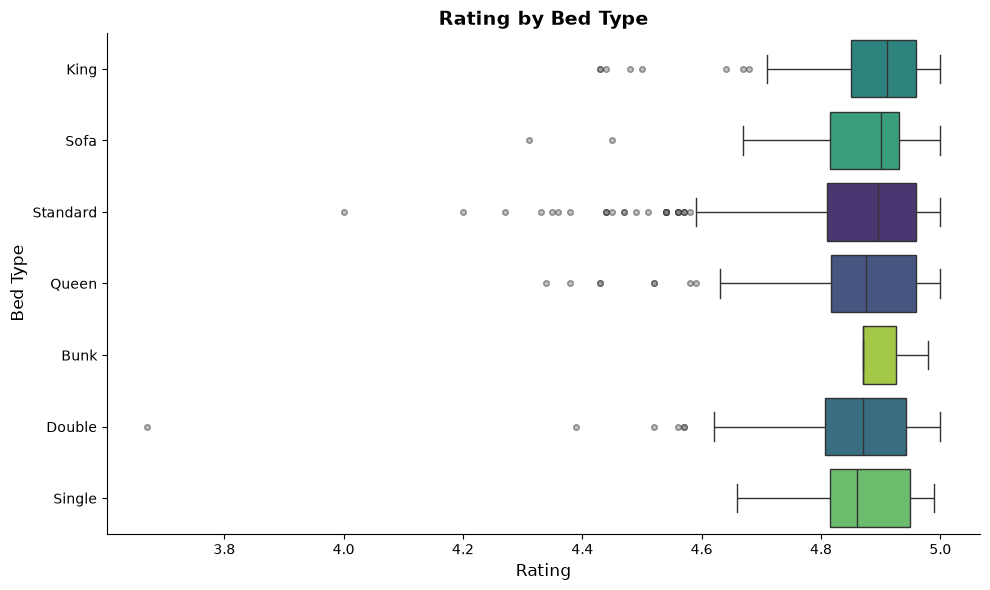

In [18]:
# Q: Does bed quality (King/Queen vs Standard/Bunk) correlate with ratings?

bivariate_boxplot(df, "Bed_Type", "Rating", top_n=7)


Box Plot — Price by Month  (top 9)
           count  median        mean         std
Month                                           
June         463   100.0  147.641469  146.022848
May          252   175.5  207.757937  133.050304
July         104   128.0  151.961538  101.960389
September     44   177.5  221.454545  164.754991
August        44   175.5  200.750000  158.154638
October       30   149.5  160.900000  103.923828
November      13   133.0  174.538462  141.556594
December       2   300.0  300.000000   89.095454
January        1   513.0  513.000000         NaN


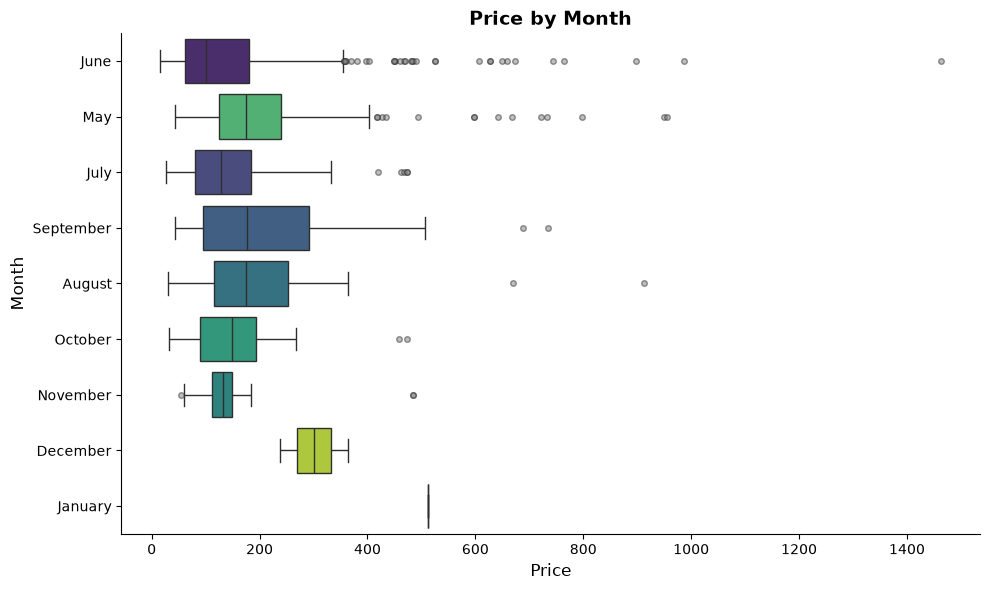

In [19]:
# Q: Is there a seasonal pricing pattern?  Are June listings priced
#    differently from the smaller September/October cohorts?

bivariate_boxplot(df, "Month", "Price", top_n=9, order_by_median=False)


Box Plot — Price_Per_Night by Month  (top 9)
           count  median        mean        std
Month                                          
June         433    20.0   28.345681  27.582415
May          252    34.7   41.200833  26.090880
July          91    23.6   28.767582  19.731056
September     37    34.5   45.134324  34.460664
August        39    34.6   39.028462  33.262358
October       21    25.2   28.949048  20.153662
November      12    25.8   36.405833  28.830717
December       2    60.0   60.000000  17.819091
January        1   102.6  102.600000        NaN


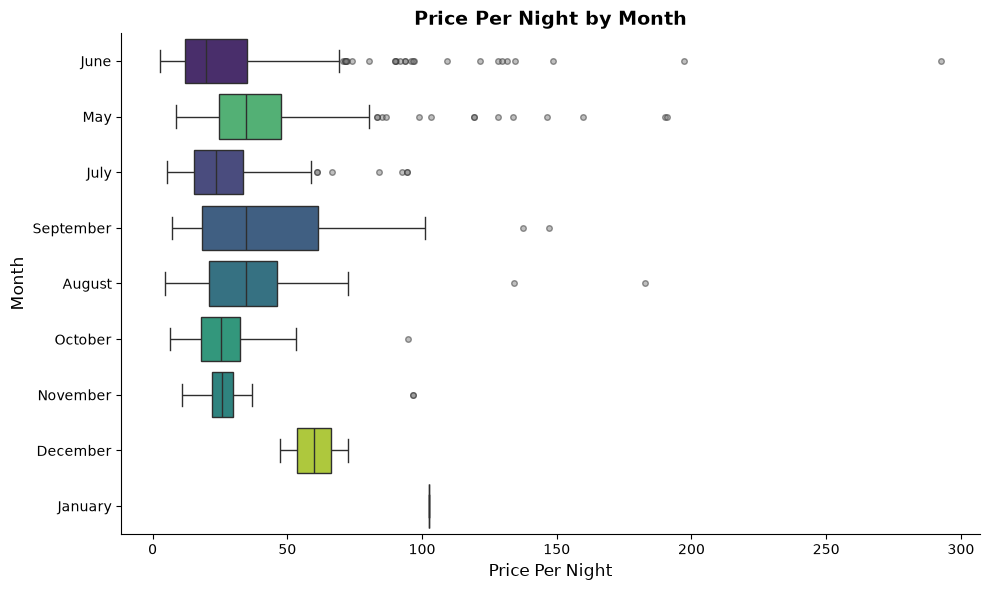

In [20]:
# Q: Does the per-night rate shift with the month of availability?

bivariate_boxplot(df, "Month", "Price_Per_Night", top_n=9, order_by_median=False)

Bar Chart — Mean Review_Count by Theme  (top 9)
           count        mean  median
Theme                               
Urban         34  309.705882   216.0
Nature       182  226.428571   159.0
Romantic      54  219.574074   190.0
Historic      20  187.650000   103.0
Beach        208  183.673077   135.0
Adventure     30  181.266667   110.0
General      318  165.849057   107.0
Luxury        89  154.089888   106.0
Family        12  137.000000   121.0


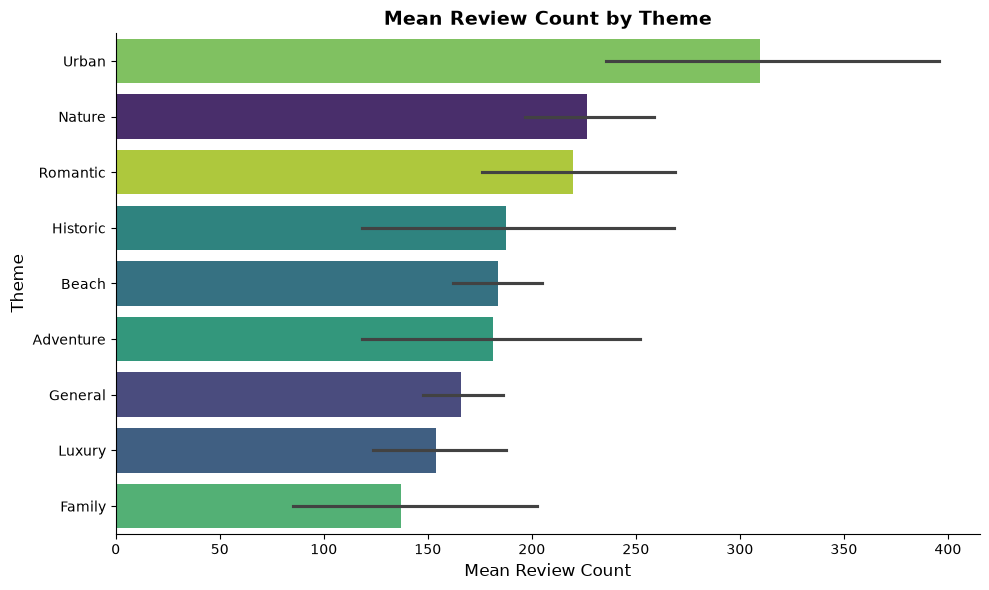

In [21]:
# Q: Which themes attract the most reviews (proxy for booking popularity)?

bivariate_bar_mean(df, "Theme", "Review_Count", top_n=9)


Bar Chart — Mean Review_Count by Property_Type  (top 10)
               count        mean  median
Property_Type                           
Guesthouse        26  335.307692   276.0
Tiny home         42  247.285714   211.0
Cottage           33  211.484848   213.0
Apartment        119  201.890756   160.0
Treehouse         37  201.297297   147.0
Condo             95  199.600000   178.0
Cabin            115  195.608696   128.0
Room              82  172.524390    95.5
Home             122  151.286885    85.5
Villa             62  123.838710    83.5


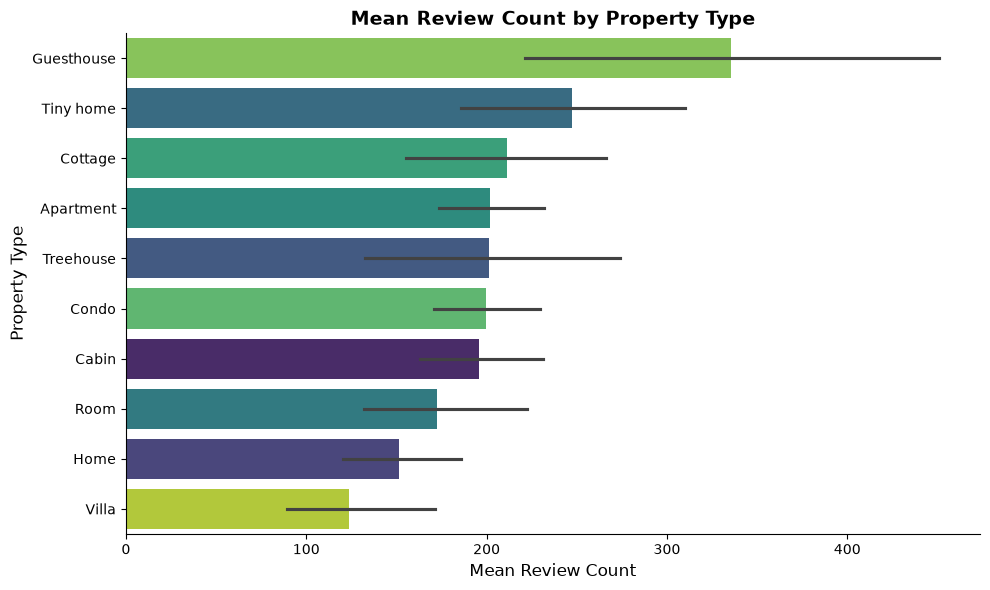

In [22]:
# Q: Which property types have the highest average review counts?

bivariate_bar_mean(df, "Property_Type", "Review_Count", top_n=10)

Bar Chart — Mean Review_Count by Country  (top 10)
             count        mean  median
Country                               
Unknown        251  246.884462   170.0
US             115  241.652174   182.0
Malaysia        26  230.423077   196.0
Mexico          39  204.692308   177.0
UK              34  192.470588   144.0
Canada          44  183.136364   124.5
Philippines     37  166.648649   145.0
Indonesia      110  143.127273   104.0
Italy           33  130.969697    87.0
Thailand        69  130.173913    98.0


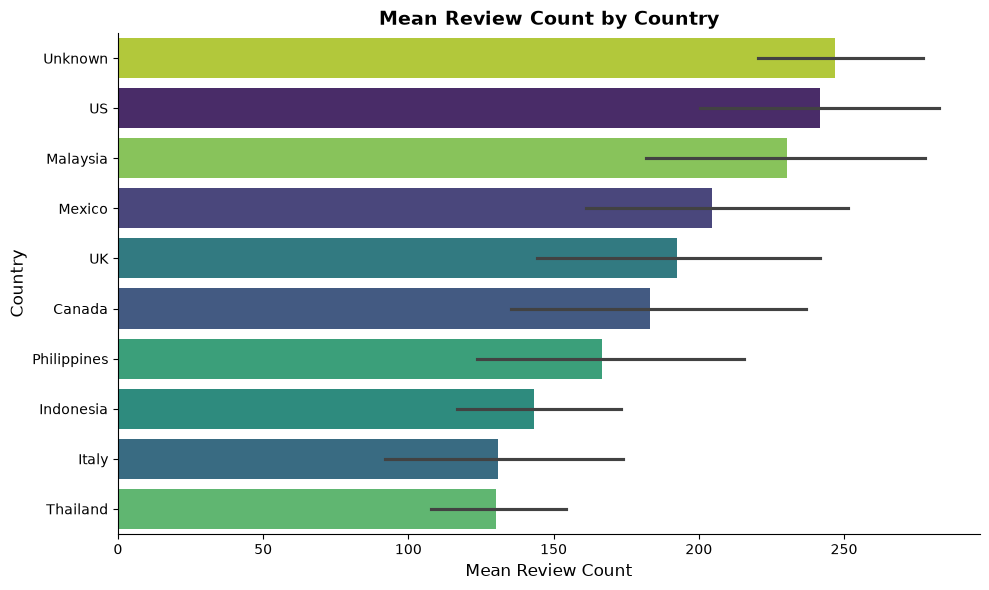

In [23]:
# Q: Are listings in certain countries reviewed far more heavily?

bivariate_bar_mean(df, "Country", "Review_Count", top_n=10)

Bar Chart — Mean Bed_Count by Theme  (top 9)
           count      mean  median
Theme                             
Family        12  2.750000     2.0
Beach        208  2.394231     2.0
General      324  2.200617     2.0
Historic      20  2.150000     2.0
Luxury        89  2.101124     2.0
Nature       182  2.076923     2.0
Adventure     30  2.066667     2.0
Romantic      54  1.925926     2.0
Urban         34  1.823529     1.5


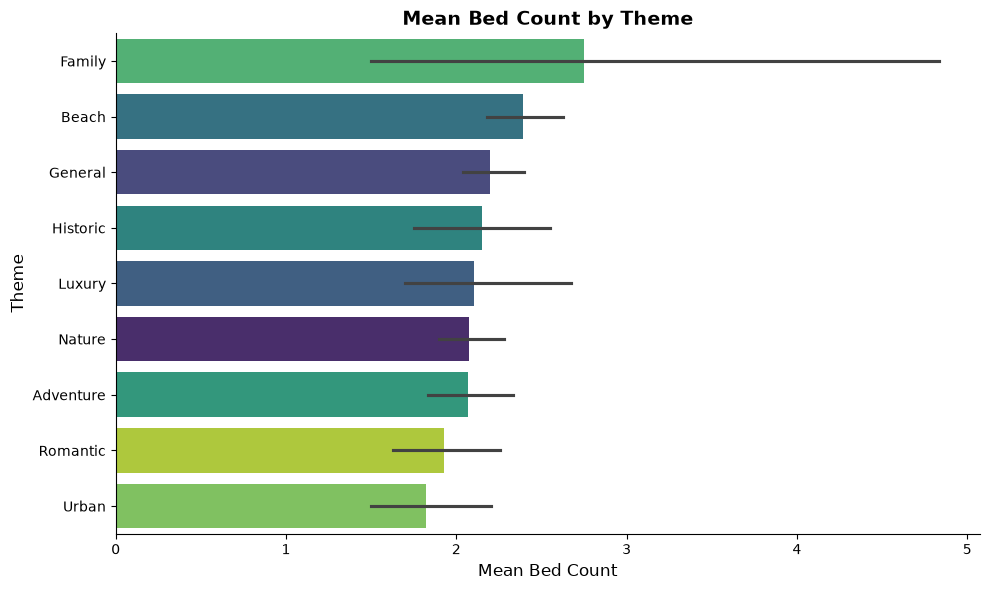

In [24]:
# Q: Do certain themes tend to have larger properties (more beds)?
#    e.g., "Family" themes should logically have higher bed counts.

bivariate_bar_mean(df, "Theme", "Bed_Count", top_n=9)

Bar Chart — Mean Bed_Count by Property_Type  (top 10)
               count      mean  median
Property_Type                         
Villa             62  3.306452     2.0
Home             123  2.601626     2.0
Guesthouse        26  2.384615     2.0
Condo             95  2.294737     2.0
Cottage           34  2.117647     2.0
Cabin            116  2.000000     2.0
Apartment        119  1.949580     2.0
Room              83  1.831325     2.0
Treehouse         37  1.783784     1.0
Tiny home         42  1.761905     2.0


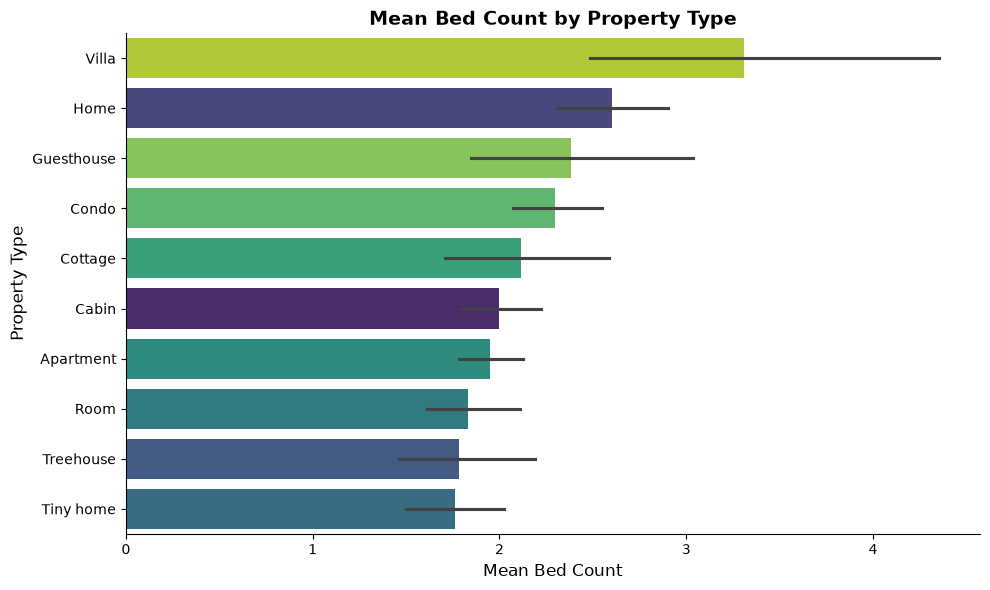

In [25]:
# Q: Which property types offer the most sleeping capacity?

bivariate_bar_mean(df, "Property_Type", "Bed_Count", top_n=10)

Bar Chart — Mean Price_Per_Night by Country  (top 10)
             count       mean  median
Country                              
US             106  49.175849   41.12
Indonesia       89  41.689326   32.33
Unknown        251  41.330717   34.80
Canada          43  41.189302   28.80
UK              29  33.127586   28.20
Philippines     32  24.000312   10.20
Italy           31  20.619677   18.20
Thailand        67  20.292687   13.00
Mexico          39  18.861795   13.50
Malaysia        25  10.448800    8.86


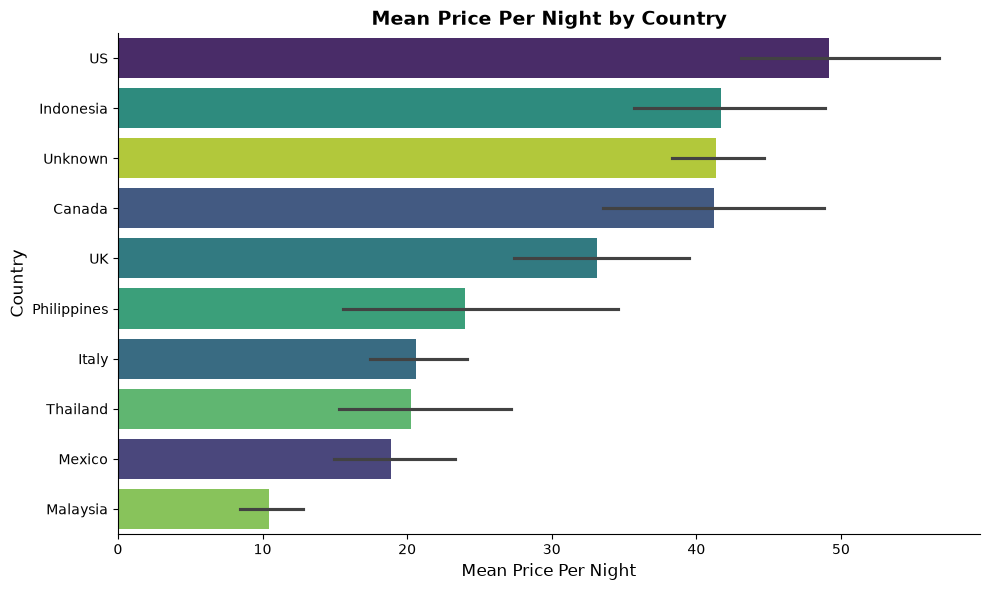

In [26]:
# Q: Which countries have the highest mean nightly rate?

bivariate_bar_mean(df, "Country", "Price_Per_Night", top_n=10)

Bar Chart — Mean Detail_Word_Count by Theme  (top 9)
           count      mean  median
Theme                             
Family        12  7.333333     7.5
Adventure     30  7.233333     8.0
Luxury        89  7.089888     7.0
Romantic      54  6.981481     7.0
Beach        208  6.855769     7.0
Historic      20  6.450000     6.5
Nature       182  6.285714     7.0
Urban         34  6.235294     6.0
General      324  5.743827     6.0


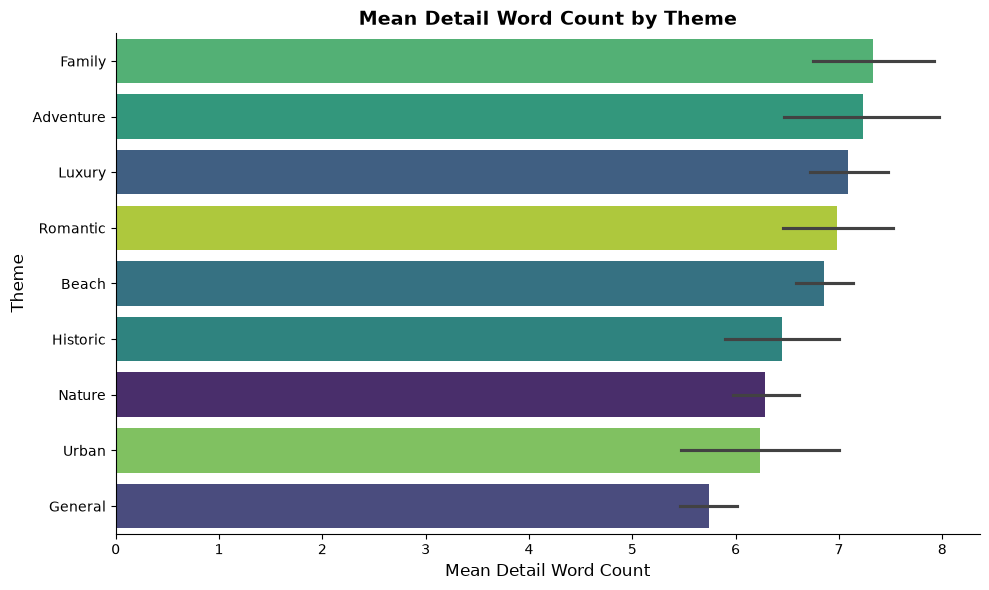

In [27]:
# Q: Do some themes have systematically longer promotional descriptions?
#    (e.g., "Luxury" hosts might write more to justify premium pricing.)

bivariate_bar_mean(df, "Theme", "Detail_Word_Count", top_n=9)

Flag Comparison — Price by Has_Pool
  Has_Pool = False  (n=835)
    Mean   : 169.28
    Median : 135.00
    Std    : 138.45

  Has_Pool = True   (n=118)
    Mean   : 186.08
    Median : 131.00
    Std    : 162.46

  Median difference : -4.00  (-3.0%)


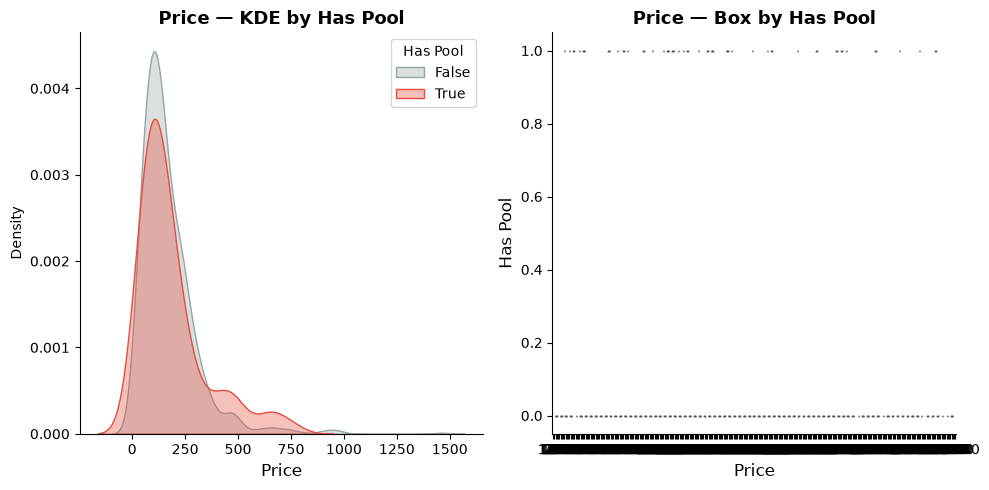

In [28]:
# Q: How much of a price premium does a pool add?  (118 listings with pool)

bivariate_flag_comparison(df, "Has_Pool", "Price")

Flag Comparison — Rating by Has_Pool
  Has_Pool = False  (n=814)
    Mean   : 4.86
    Median : 4.90
    Std    : 0.14

  Has_Pool = True   (n=117)
    Mean   : 4.86
    Median : 4.87
    Std    : 0.13

  Median difference : -0.03  (-0.6%)


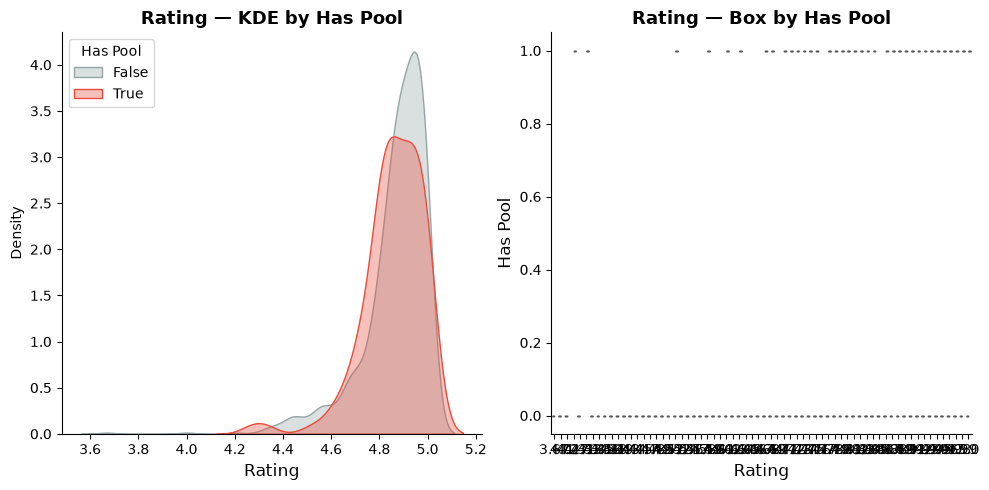

In [29]:
# Q: Do pool properties actually get better guest ratings?

bivariate_flag_comparison(df, "Has_Pool", "Rating")

Flag Comparison — Price by Is_Near_Beach
  Is_Near_Beach = False  (n=757)
    Mean   : 155.72
    Median : 124.00
    Std    : 123.19

  Is_Near_Beach = True   (n=196)
    Mean   : 231.74
    Median : 182.00
    Std    : 185.81

  Median difference : +58.00  (+46.8%)


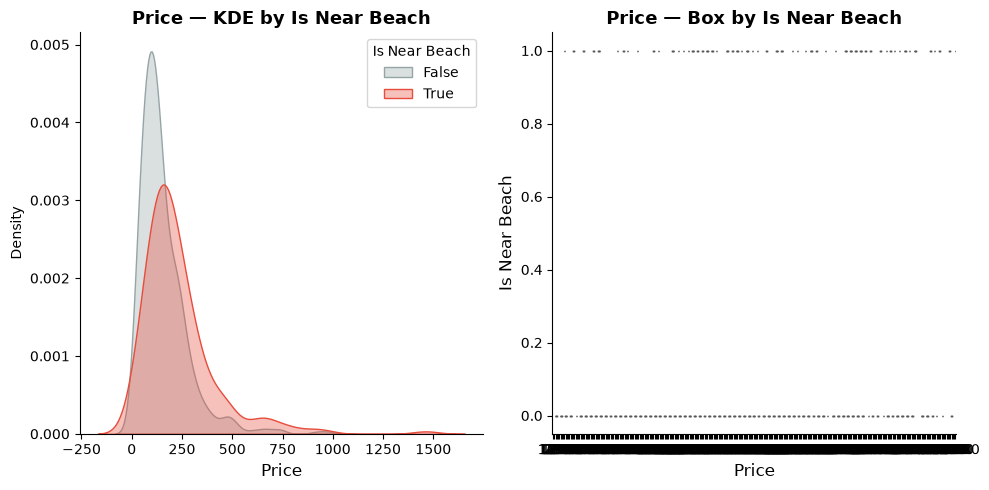

In [30]:
# Q: What's the beach proximity premium?  (196 beach listings — largest flag)

bivariate_flag_comparison(df, "Is_Near_Beach", "Price")

Flag Comparison — Rating by Is_Near_Beach
  Is_Near_Beach = False  (n=738)
    Mean   : 4.87
    Median : 4.90
    Std    : 0.14

  Is_Near_Beach = True   (n=193)
    Mean   : 4.84
    Median : 4.88
    Std    : 0.14

  Median difference : -0.02  (-0.4%)


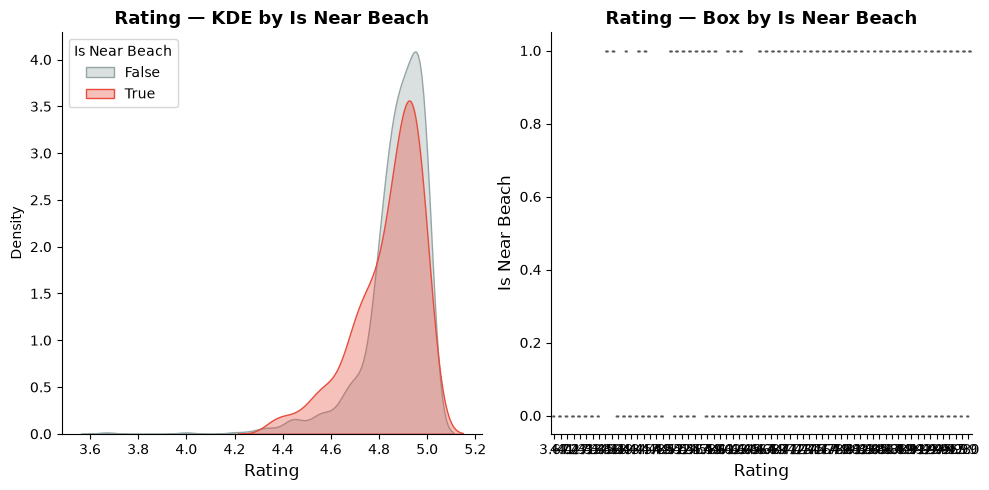

In [31]:
# Q: Do beach-adjacent properties earn higher guest satisfaction?

bivariate_flag_comparison(df, "Is_Near_Beach", "Rating")

Flag Comparison — Price by Has_Waterfront
  Has_Waterfront = False  (n=876)
    Mean   : 166.98
    Median : 131.00
    Std    : 139.46

  Has_Waterfront = True   (n=77)
    Mean   : 221.19
    Median : 184.00
    Std    : 157.21

  Median difference : +53.00  (+40.5%)


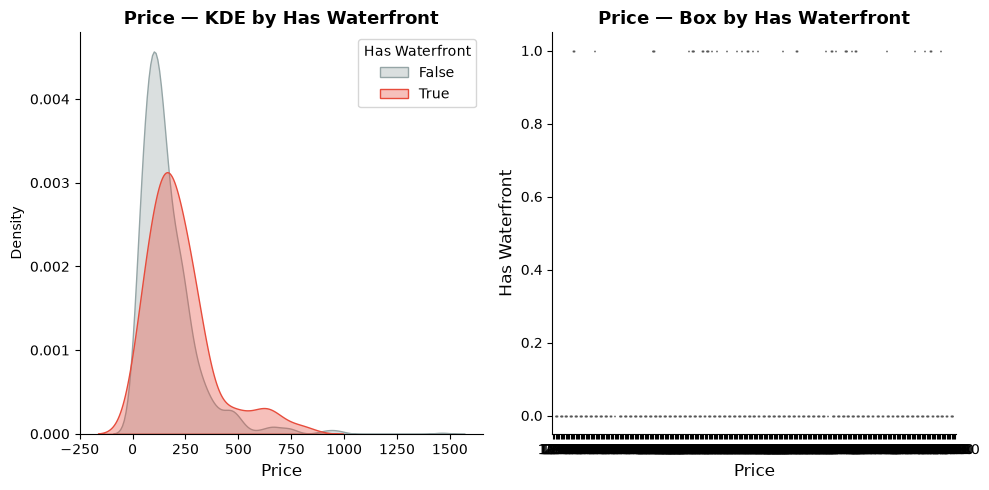

In [32]:
# Q: Waterfront is a step beyond "near beach" — how much more do
#    waterfront properties charge?  (77 listings)

bivariate_flag_comparison(df, "Has_Waterfront", "Price")

Flag Comparison — Rating by Has_Waterfront
  Has_Waterfront = False  (n=854)
    Mean   : 4.86
    Median : 4.89
    Std    : 0.14

  Has_Waterfront = True   (n=77)
    Mean   : 4.85
    Median : 4.89
    Std    : 0.15

  Median difference : +0.00  (+0.0%)


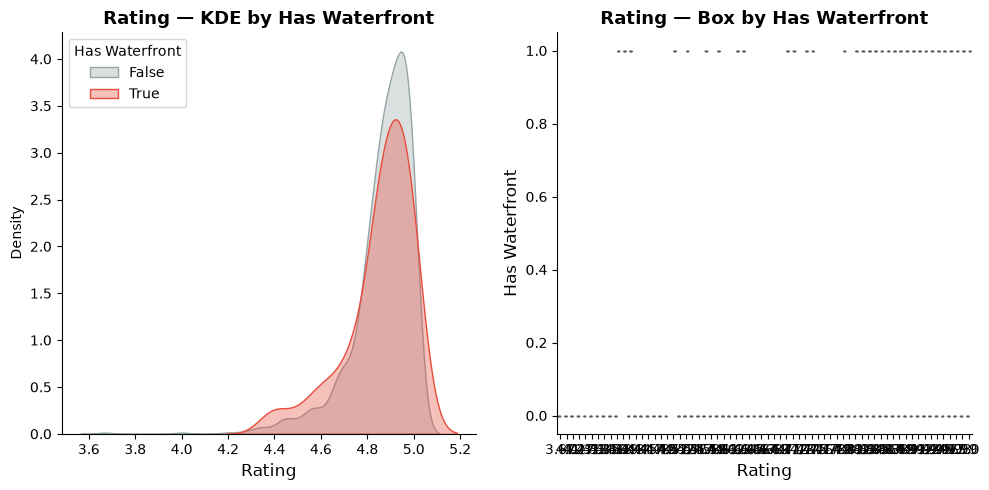

In [33]:
# Q: Are waterfront properties rated higher than non-waterfront?

bivariate_flag_comparison(df, "Has_Waterfront", "Rating")

Flag Comparison — Price by Has_Hot_Tub
  Has_Hot_Tub = False  (n=919)
    Mean   : 167.13
    Median : 132.00
    Std    : 139.24

  Has_Hot_Tub = True   (n=34)
    Mean   : 285.53
    Median : 244.00
    Std    : 160.10

  Median difference : +112.00  (+84.8%)


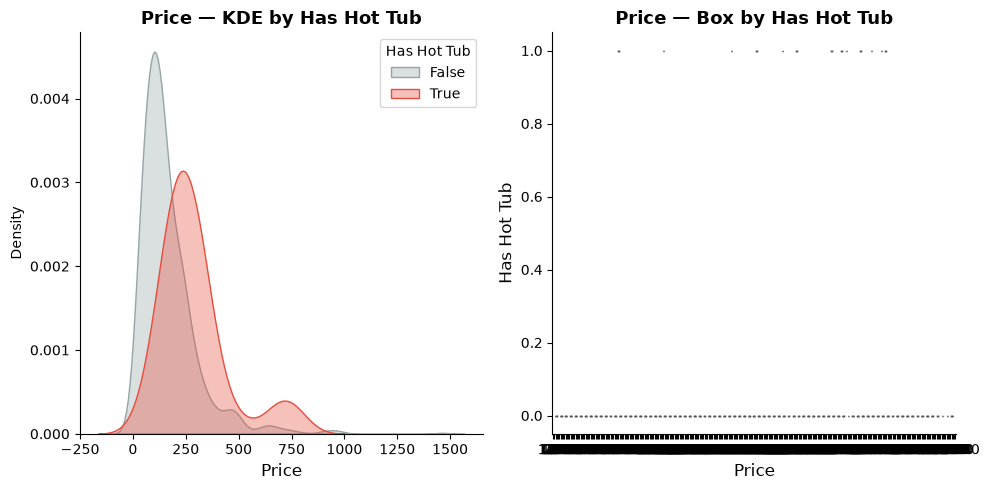

In [34]:
# Q: How large is the hot-tub premium?  (34 listings — smaller sample)

bivariate_flag_comparison(df, "Has_Hot_Tub", "Price")

Flag Comparison — Price by Is_Rural
  Is_Rural = False  (n=889)
    Mean   : 171.57
    Median : 134.00
    Std    : 143.60

  Is_Rural = True   (n=64)
    Mean   : 168.38
    Median : 136.00
    Std    : 112.11

  Median difference : +2.00  (+1.5%)


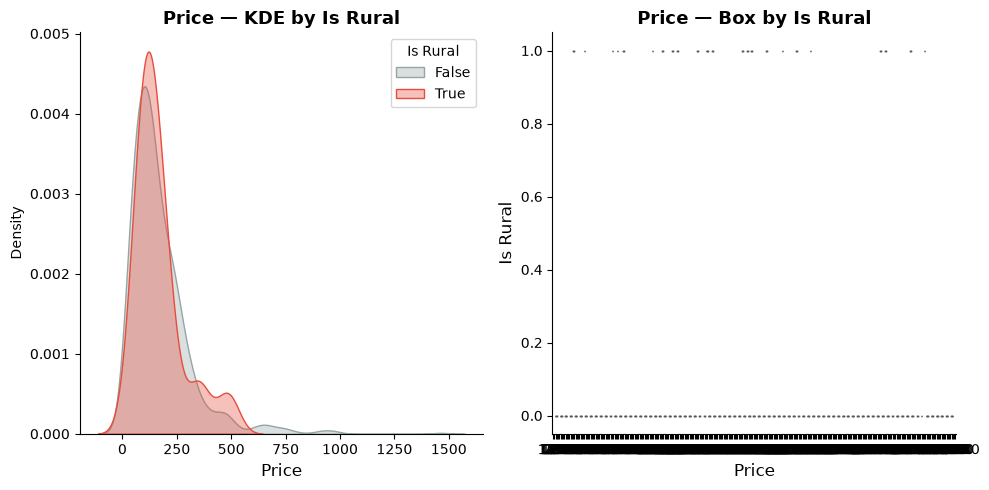

In [35]:
# Q: Are rural/secluded getaways cheaper or more expensive than the rest?
#    (64 listings)

bivariate_flag_comparison(df, "Is_Rural", "Price")

Flag Comparison — Rating by Is_Rural
  Is_Rural = False  (n=867)
    Mean   : 4.86
    Median : 4.89
    Std    : 0.14

  Is_Rural = True   (n=64)
    Mean   : 4.90
    Median : 4.93
    Std    : 0.15

  Median difference : +0.04  (+0.8%)


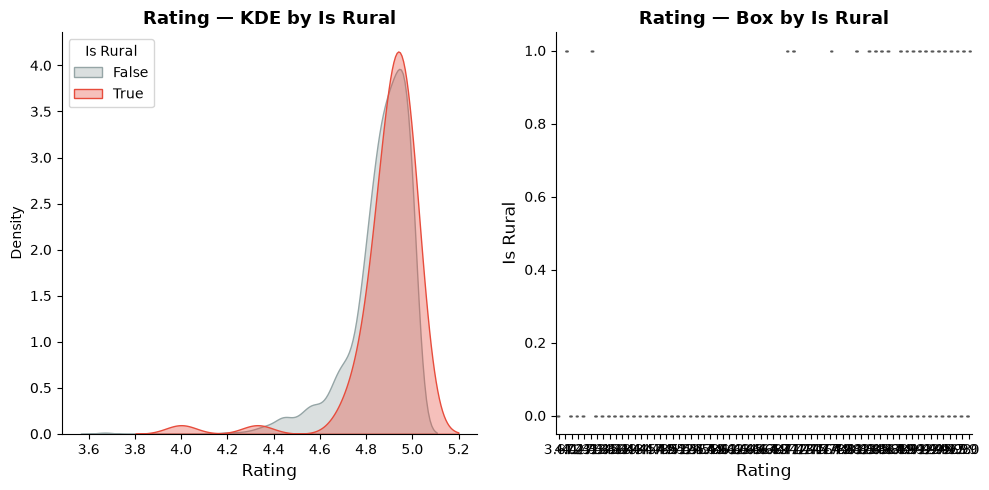

In [36]:
# Q: Do rural properties receive higher ratings (peaceful retreat effect)?

bivariate_flag_comparison(df, "Is_Rural", "Rating")

Flag Comparison — Price by Is_Mountain
  Is_Mountain = False  (n=929)
    Mean   : 171.12
    Median : 133.00
    Std    : 142.57

  Is_Mountain = True   (n=24)
    Mean   : 180.54
    Median : 160.00
    Std    : 102.05

  Median difference : +27.00  (+20.3%)


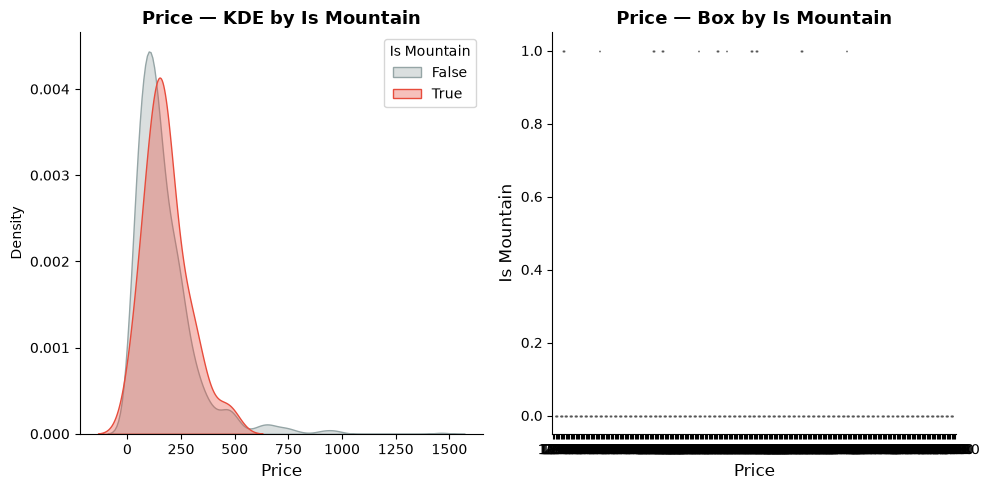

In [37]:
# Q: Mountain listings — premium or budget?  (24 listings — use with caution)

bivariate_flag_comparison(df, "Is_Mountain", "Price")

Flag Comparison — Price by Is_New_Listing
  Is_New_Listing = False  (n=937)
    Mean   : 170.36
    Median : 134.00
    Std    : 140.95

  Is_New_Listing = True   (n=16)
    Mean   : 229.88
    Median : 231.00
    Std    : 173.65

  Median difference : +97.00  (+72.4%)


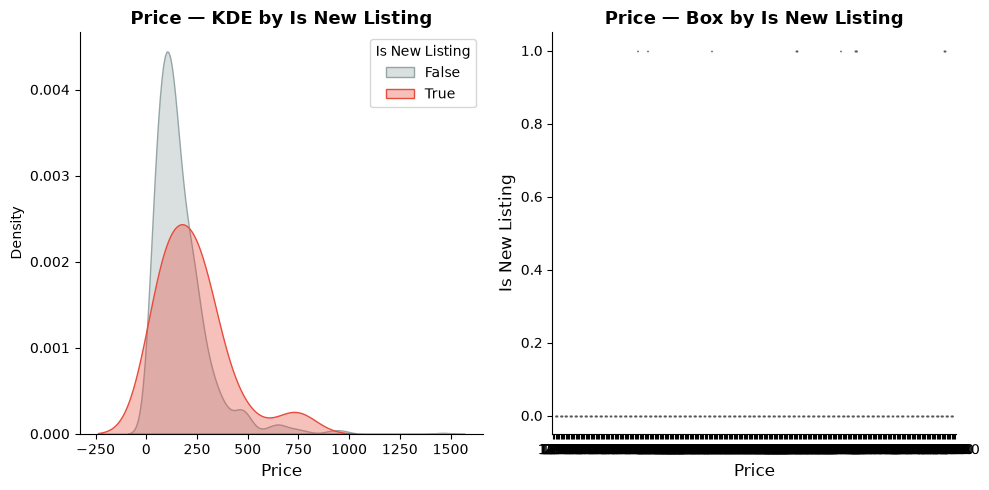

In [38]:
# Q: Do brand-new listings price themselves lower to attract initial
#    bookings, or do they come in at market rate?  (16 new listings)

bivariate_flag_comparison(df, "Is_New_Listing", "Price")

Flag Comparison — Review_Count by Is_Near_Beach
  Is_Near_Beach = False  (n=751)
    Mean   : 191.94
    Median : 139.00
    Std    : 189.31

  Is_Near_Beach = True   (n=196)
    Mean   : 178.30
    Median : 124.50
    Std    : 169.41

  Median difference : -14.50  (-10.4%)


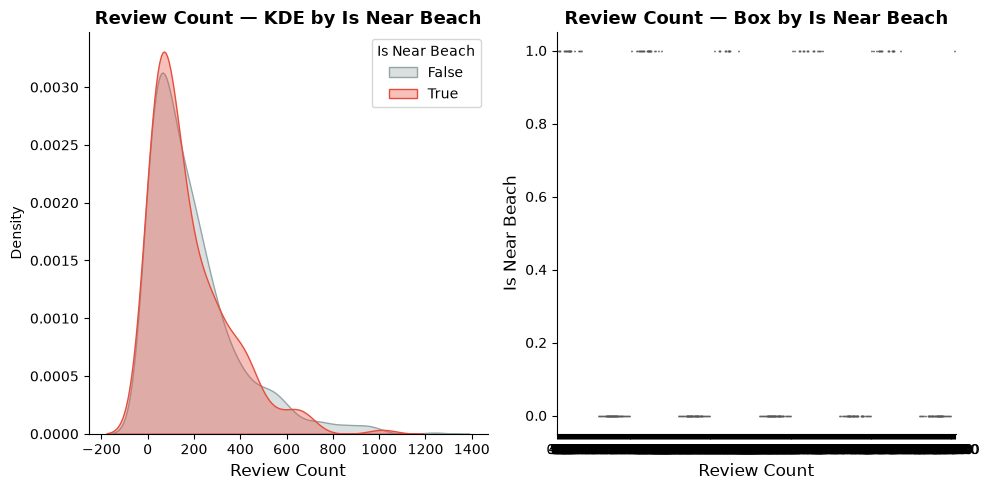

In [39]:
# Q: Do beach properties accumulate more reviews (higher booking velocity)?

bivariate_flag_comparison(df, "Is_Near_Beach", "Review_Count")

Flag Comparison — Review_Count by Has_Pool
  Has_Pool = False  (n=829)
    Mean   : 195.10
    Median : 145.00
    Std    : 188.57

  Has_Pool = True   (n=118)
    Mean   : 147.08
    Median : 105.50
    Std    : 155.40

  Median difference : -39.50  (-27.2%)


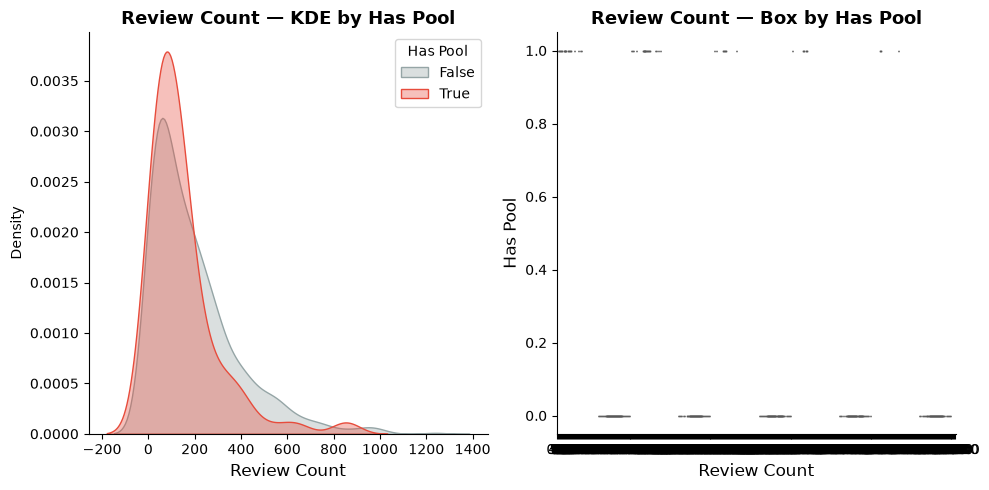

In [40]:
# Q: Are pool properties more frequently booked (more reviews)?

bivariate_flag_comparison(df, "Has_Pool", "Review_Count")


Cross-tab — Theme × Property_Type (%)
Property_Type  Apartment      Cabin      Condo    Cottage  Guesthouse       Home       Room  Tiny home  Treehouse      Villa
Theme                                                                                                                       
Adventure       3.703704  18.518519   3.703704  11.111111    0.000000  18.518519   7.407407  33.333333   0.000000   3.703704
Beach          21.637427   3.508772  23.391813   5.263158    3.508772  20.467836   6.432749   3.508772   0.000000  12.280702
Family         10.000000  10.000000  10.000000   0.000000    0.000000  30.000000  30.000000   0.000000   0.000000  10.000000
General        14.741036   9.561753  11.155378   4.780876    4.780876  22.709163  17.928287   5.577689   1.992032   6.772908
Historic       20.000000   6.666667   0.000000  20.000000    6.666667   0.000000  46.666667   0.000000   0.000000   0.000000
Luxury         29.824561   5.263158  15.789474   0.000000    0.000000   8.771930  14.03

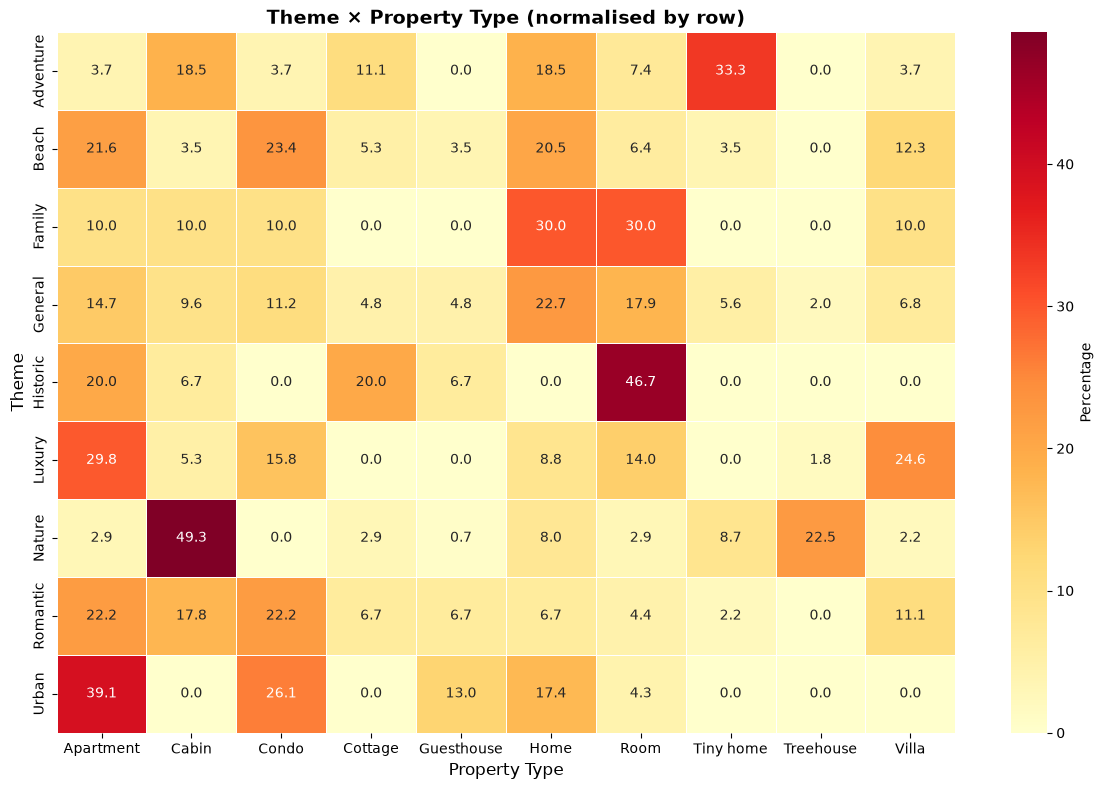

Property_Type,Apartment,Cabin,Condo,Cottage,Guesthouse,Home,Room,Tiny home,Treehouse,Villa
Theme,,,,,,,,,,
Adventure,3.703704,18.518519,3.703704,11.111111,0.000000,18.518519,7.407407,33.333333,0.000000,3.703704
Beach,21.637427,3.508772,23.391813,5.263158,3.508772,20.467836,6.432749,3.508772,0.000000,12.280702
Family,10.000000,10.000000,10.000000,0.000000,0.000000,30.000000,30.000000,0.000000,0.000000,10.000000
General,14.741036,9.561753,11.155378,4.780876,4.780876,22.709163,17.928287,5.577689,1.992032,6.772908
Historic,20.000000,6.666667,0.000000,20.000000,6.666667,0.000000,46.666667,0.000000,0.000000,0.000000
Luxury,29.824561,5.263158,15.789474,0.000000,0.000000,8.771930,14.035088,0.000000,1.754386,24.561404
Nature,2.898551,49.275362,0.000000,2.898551,0.724638,7.971014,2.898551,8.695652,22.463768,2.173913
Romantic,22.222222,17.777778,22.222222,6.666667,6.666667,6.666667,4.444444,2.222222,0.000000,11.111111
Urban,39.130435,0.000000,26.086957,0.000000,13.043478,17.391304,4.347826,0.000000,0.000000,0.000000


In [41]:
# Q: Which property types dominate each theme?  Are Cabins mostly "Nature"?
#    Are Apartments mostly "Urban"?

categorical_crosstab_heatmap(df, "Theme", "Property_Type", top_n_row=9, top_n_col=10)


Cross-tab — Theme × Bed_Type (%)
Bed_Type       Bunk     Double       King      Queen    Single      Sofa   Standard
Theme                                                                              
Adventure  0.000000   3.333333  10.000000  20.000000  0.000000  0.000000  66.666667
Beach      0.000000   4.807692  10.576923  20.673077  0.000000  0.961538  62.980769
Family     0.000000   8.333333  25.000000   0.000000  8.333333  8.333333  50.000000
General    0.617284  11.728395  10.493827  12.345679  1.234568  3.395062  60.185185
Historic   0.000000   0.000000  15.000000  20.000000  5.000000  0.000000  60.000000
Luxury     0.000000  12.359551  12.359551  21.348315  1.123596  2.247191  50.561798
Nature     0.000000  12.087912   9.340659  19.230769  1.648352  2.747253  54.945055
Romantic   1.851852   7.407407  20.370370  11.111111  1.851852  0.000000  57.407407
Urban      0.000000  11.764706  17.647059  29.411765  0.000000  5.882353  35.294118


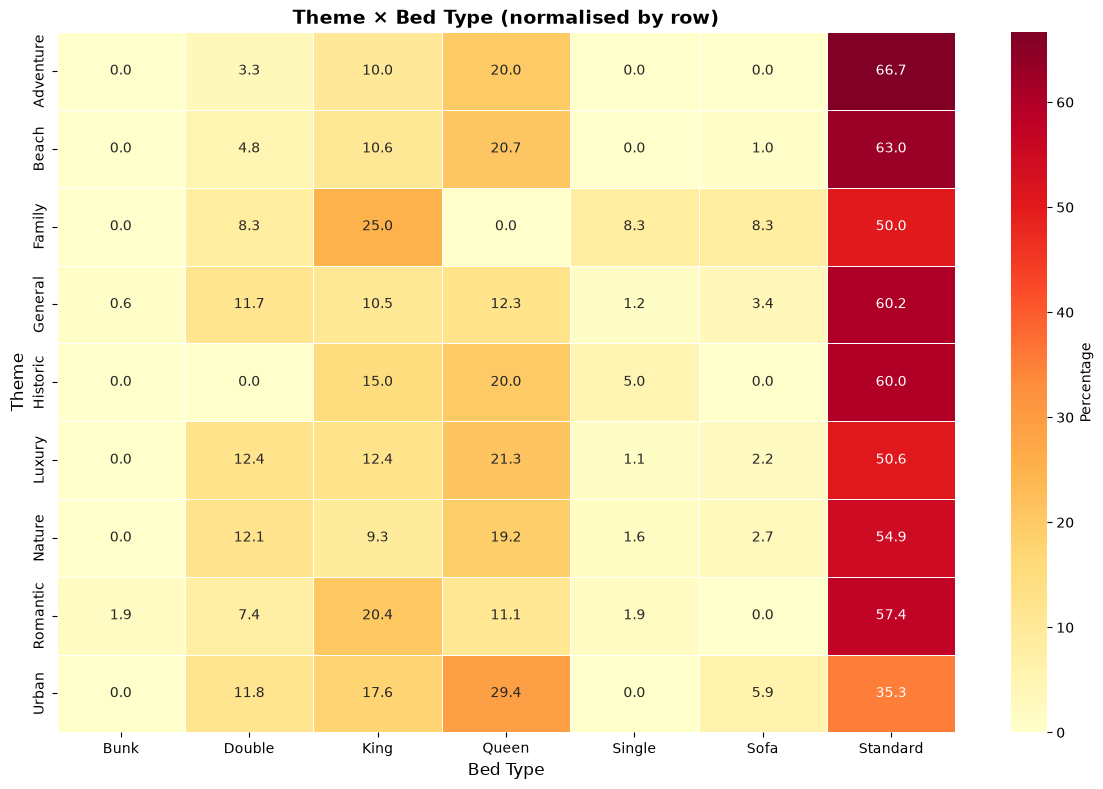

Bed_Type,Bunk,Double,King,Queen,Single,Sofa,Standard
Theme,,,,,,,
Adventure,0.000000,3.333333,10.000000,20.000000,0.000000,0.000000,66.666667
Beach,0.000000,4.807692,10.576923,20.673077,0.000000,0.961538,62.980769
Family,0.000000,8.333333,25.000000,0.000000,8.333333,8.333333,50.000000
General,0.617284,11.728395,10.493827,12.345679,1.234568,3.395062,60.185185
Historic,0.000000,0.000000,15.000000,20.000000,5.000000,0.000000,60.000000
Luxury,0.000000,12.359551,12.359551,21.348315,1.123596,2.247191,50.561798
Nature,0.000000,12.087912,9.340659,19.230769,1.648352,2.747253,54.945055
Romantic,1.851852,7.407407,20.370370,11.111111,1.851852,0.000000,57.407407
Urban,0.000000,11.764706,17.647059,29.411765,0.000000,5.882353,35.294118


In [42]:
# Q: Are King beds concentrated in "Romantic" / "Luxury" themes?
#    Are Bunk beds more common in "Family" listings?

categorical_crosstab_heatmap(df, "Theme", "Bed_Type", top_n_row=9, top_n_col=7)

Cross-tab — Country × Theme (%)
Theme        Adventure      Beach    Family    General   Historic     Luxury     Nature   Romantic      Urban
Country                                                                                                      
Canada       13.636364  15.909091  2.272727  11.363636   2.272727   2.272727  38.636364  11.363636   2.272727
Indonesia     0.909091  20.909091  0.000000  31.818182   0.909091  25.454545  14.545455   5.454545   0.000000
Italy         0.000000   2.941176  5.882353  73.529412   2.941176   0.000000   5.882353   8.823529   0.000000
Malaysia      0.000000  19.230769  0.000000  38.461538   0.000000  19.230769   0.000000   3.846154  19.230769
Mexico        0.000000  27.500000  2.500000  32.500000   5.000000  12.500000   7.500000   2.500000  10.000000
Philippines   8.108108  27.027027  2.702703  21.621622   0.000000   0.000000  16.216216  18.918919   5.405405
Thailand      0.000000  39.130435  1.449275  30.434783   0.000000  15.942029   1.449275 

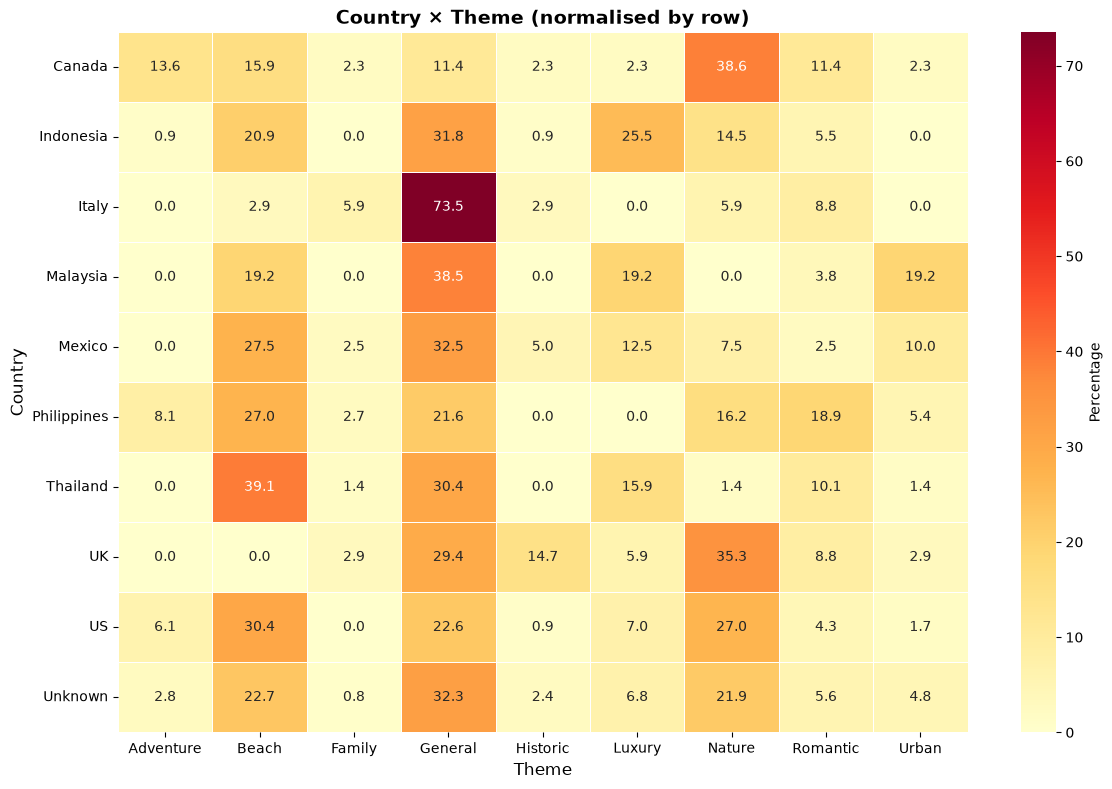

Theme,Adventure,Beach,Family,General,Historic,Luxury,Nature,Romantic,Urban
Country,,,,,,,,,
Canada,13.636364,15.909091,2.272727,11.363636,2.272727,2.272727,38.636364,11.363636,2.272727
Indonesia,0.909091,20.909091,0.000000,31.818182,0.909091,25.454545,14.545455,5.454545,0.000000
Italy,0.000000,2.941176,5.882353,73.529412,2.941176,0.000000,5.882353,8.823529,0.000000
Malaysia,0.000000,19.230769,0.000000,38.461538,0.000000,19.230769,0.000000,3.846154,19.230769
Mexico,0.000000,27.500000,2.500000,32.500000,5.000000,12.500000,7.500000,2.500000,10.000000
Philippines,8.108108,27.027027,2.702703,21.621622,0.000000,0.000000,16.216216,18.918919,5.405405
Thailand,0.000000,39.130435,1.449275,30.434783,0.000000,15.942029,1.449275,10.144928,1.449275
UK,0.000000,0.000000,2.941176,29.411765,14.705882,5.882353,35.294118,8.823529,2.941176
US,6.086957,30.434783,0.000000,22.608696,0.869565,6.956522,26.956522,4.347826,1.739130


In [43]:
# Q: Do certain countries skew toward specific themes?
#    e.g., Indonesia → Beach/Nature, US → spread across multiple themes?

categorical_crosstab_heatmap(df, "Country", "Theme", top_n_row=10, top_n_col=9)

Cross-tab — Property_Type × Bed_Type (%)
Bed_Type           Bunk     Double       King      Queen    Single      Sofa   Standard
Property_Type                                                                          
Apartment      0.000000   5.882353  12.605042  15.966387  0.000000  2.521008  63.025210
Cabin          0.000000  10.344828  12.931034  21.551724  2.586207  3.448276  49.137931
Condo          0.000000   5.263158   3.157895   9.473684  0.000000  3.157895  78.947368
Cottage        0.000000  14.705882   5.882353  26.470588  0.000000  0.000000  52.941176
Guesthouse     0.000000   7.692308   3.846154  26.923077  0.000000  3.846154  57.692308
Home           0.000000   8.130081   8.130081  14.634146  0.000000  0.000000  69.105691
Room           0.000000  12.048193  14.457831  12.048193  1.204819  8.433735  51.807229
Tiny home      0.000000   7.142857   4.761905  33.333333  4.761905  0.000000  50.000000
Treehouse      0.000000  16.216216  10.810811  16.216216  2.702703  0.000000  5

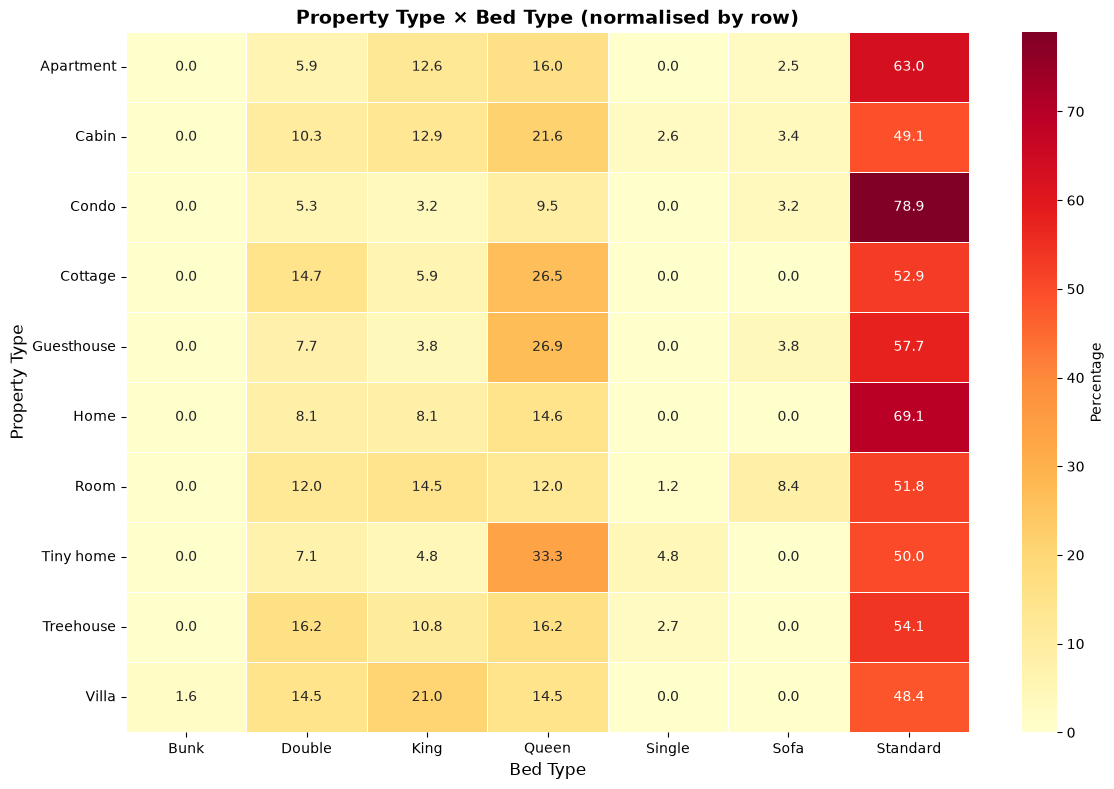

Bed_Type,Bunk,Double,King,Queen,Single,Sofa,Standard
Property_Type,,,,,,,
Apartment,0.000000,5.882353,12.605042,15.966387,0.000000,2.521008,63.025210
Cabin,0.000000,10.344828,12.931034,21.551724,2.586207,3.448276,49.137931
Condo,0.000000,5.263158,3.157895,9.473684,0.000000,3.157895,78.947368
Cottage,0.000000,14.705882,5.882353,26.470588,0.000000,0.000000,52.941176
Guesthouse,0.000000,7.692308,3.846154,26.923077,0.000000,3.846154,57.692308
Home,0.000000,8.130081,8.130081,14.634146,0.000000,0.000000,69.105691
Room,0.000000,12.048193,14.457831,12.048193,1.204819,8.433735,51.807229
Tiny home,0.000000,7.142857,4.761905,33.333333,4.761905,0.000000,50.000000
Treehouse,0.000000,16.216216,10.810811,16.216216,2.702703,0.000000,54.054054


In [44]:
# Q: What bed configurations are typical for each property type?
#    e.g., Villas → King beds?  Tiny homes → Single?

categorical_crosstab_heatmap(df, "Property_Type", "Bed_Type", top_n_row=10, top_n_col=7)

Stacked Bar — Theme composition within Property_Type  (top 10)
_sec           Adventure  Beach  General  Historic  Luxury  Nature  Other  Romantic  Urban
Property_Type                                                                             
Guesthouse           0.0   23.1     46.2       3.8     0.0     3.8    0.0      11.5   11.5
Cottage              8.8   26.5     35.3       8.8     0.0    11.8    0.0       8.8    0.0
Treehouse            0.0    0.0     13.5       0.0     2.7    83.8    0.0       0.0    0.0
Tiny home           21.4   14.3     33.3       0.0     0.0    28.6    0.0       2.4    0.0
Villa                1.6   33.9     27.4       0.0    22.6     4.8    1.6       8.1    0.0
Room                 2.4   13.3     54.2       8.4     9.6     4.8    3.6       2.4    1.2
Condo                1.1   42.1     29.5       0.0     9.5     0.0    1.1      10.5    6.3
Cabin                4.3    5.2     20.7       0.9     2.6    58.6    0.9       6.9    0.0
Apartment            0.8   

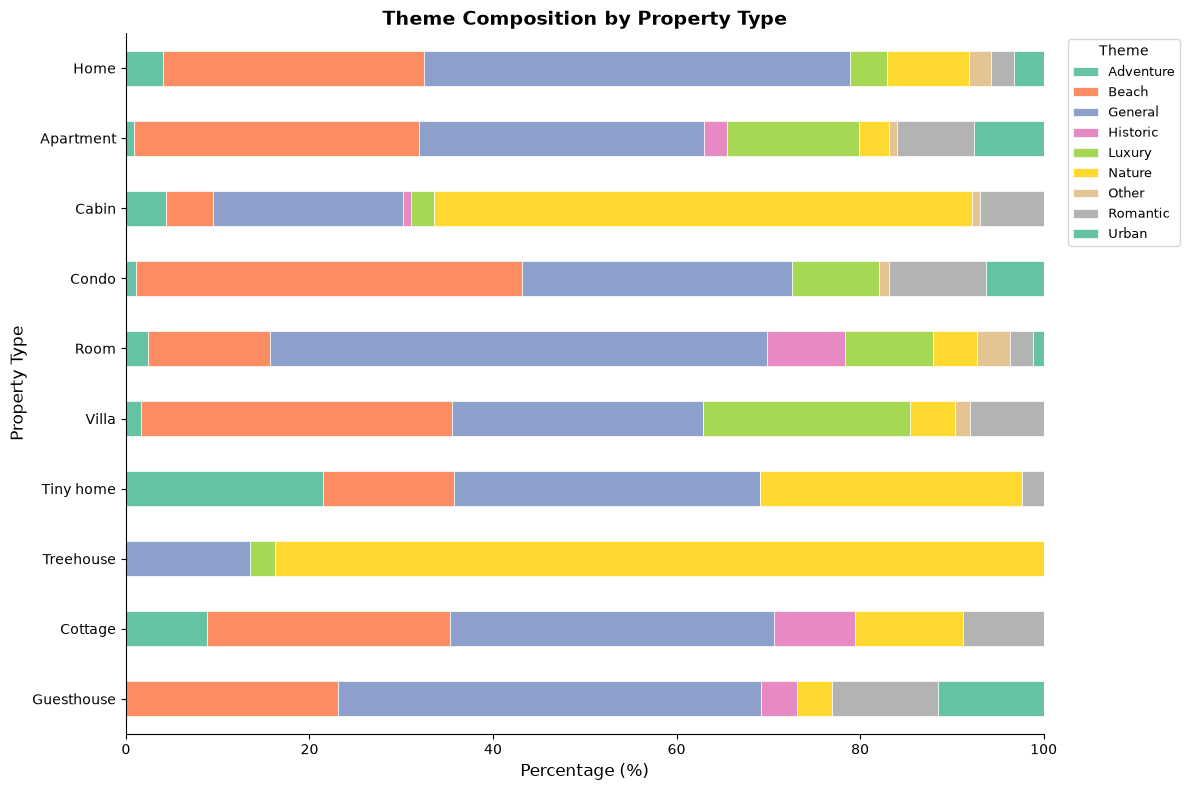

In [45]:
# Q: What's the thematic composition of each property type?
#    (100% stacked bar — shows proportional breakdown)

bivariate_stacked_bar(df, "Property_Type", "Theme", top_n_primary=10, top_n_secondary=8)

Stacked Bar — Theme composition within Country  (top 10)
_sec         Adventure  Beach  General  Historic  Luxury  Nature  Other  Romantic  Urban
Country                                                                                 
Malaysia           0.0   19.2     38.5       0.0    19.2     0.0    0.0       3.8   19.2
Italy              0.0    2.9     73.5       2.9     0.0     5.9    5.9       8.8    0.0
UK                 0.0    0.0     29.4      14.7     5.9    35.3    2.9       8.8    2.9
Philippines        8.1   27.0     21.6       0.0     0.0    16.2    2.7      18.9    5.4
Mexico             0.0   27.5     32.5       5.0    12.5     7.5    2.5       2.5   10.0
Canada            13.6   15.9     11.4       2.3     2.3    38.6    2.3      11.4    2.3
Thailand           0.0   39.1     30.4       0.0    15.9     1.4    1.4      10.1    1.4
Indonesia          0.9   20.9     31.8       0.9    25.5    14.5    0.0       5.5    0.0
US                 6.1   30.4     22.6       0.9     

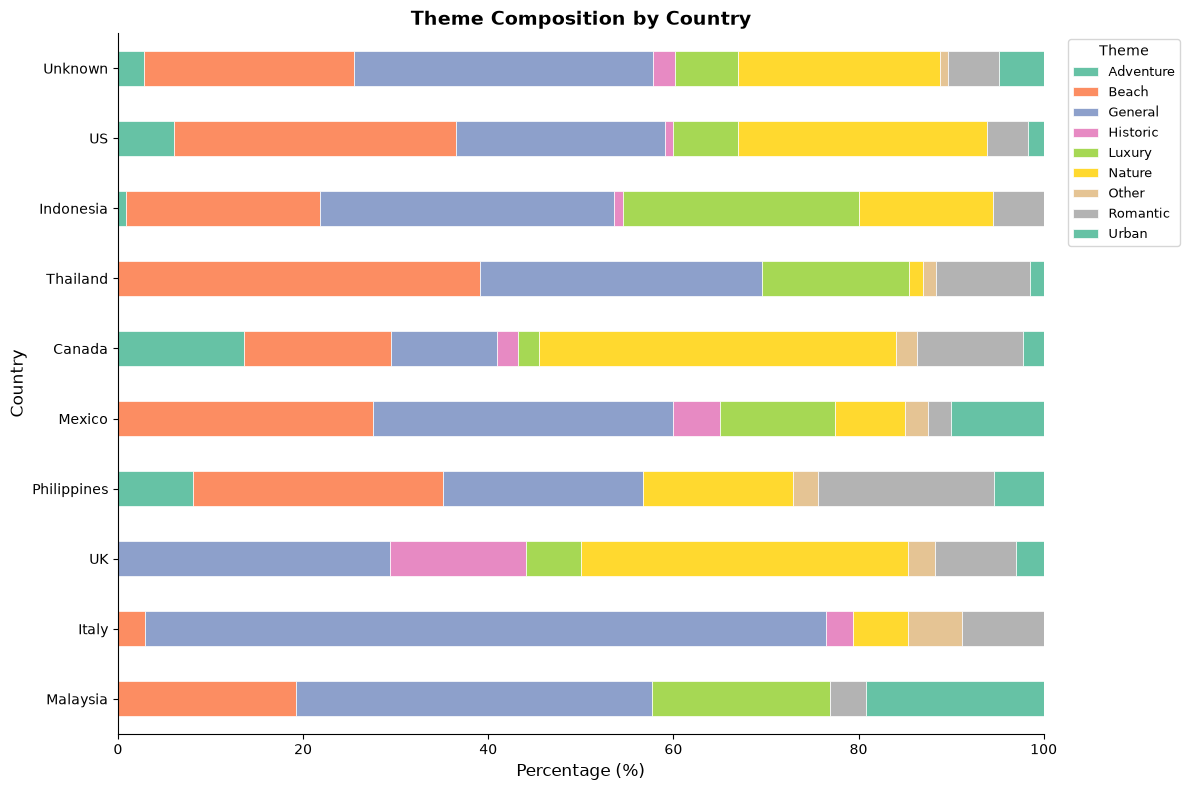

In [46]:
# Q: What's the thematic composition of listings per country?

bivariate_stacked_bar(df, "Country", "Theme", top_n_primary=10, top_n_secondary=8)

Stacked Bar — Bed_Type composition within Theme  (top 9)
_sec       Bunk  Double  King  Queen  Single  Sofa  Standard
Theme                                                       
Family      0.0     8.3  25.0    0.0     8.3   8.3      50.0
Historic    0.0     0.0  15.0   20.0     5.0   0.0      60.0
Adventure   0.0     3.3  10.0   20.0     0.0   0.0      66.7
Urban       0.0    11.8  17.6   29.4     0.0   5.9      35.3
Romantic    1.9     7.4  20.4   11.1     1.9   0.0      57.4
Luxury      0.0    12.4  12.4   21.3     1.1   2.2      50.6
Nature      0.0    12.1   9.3   19.2     1.6   2.7      54.9
Beach       0.0     4.8  10.6   20.7     0.0   1.0      63.0
General     0.6    11.7  10.5   12.3     1.2   3.4      60.2


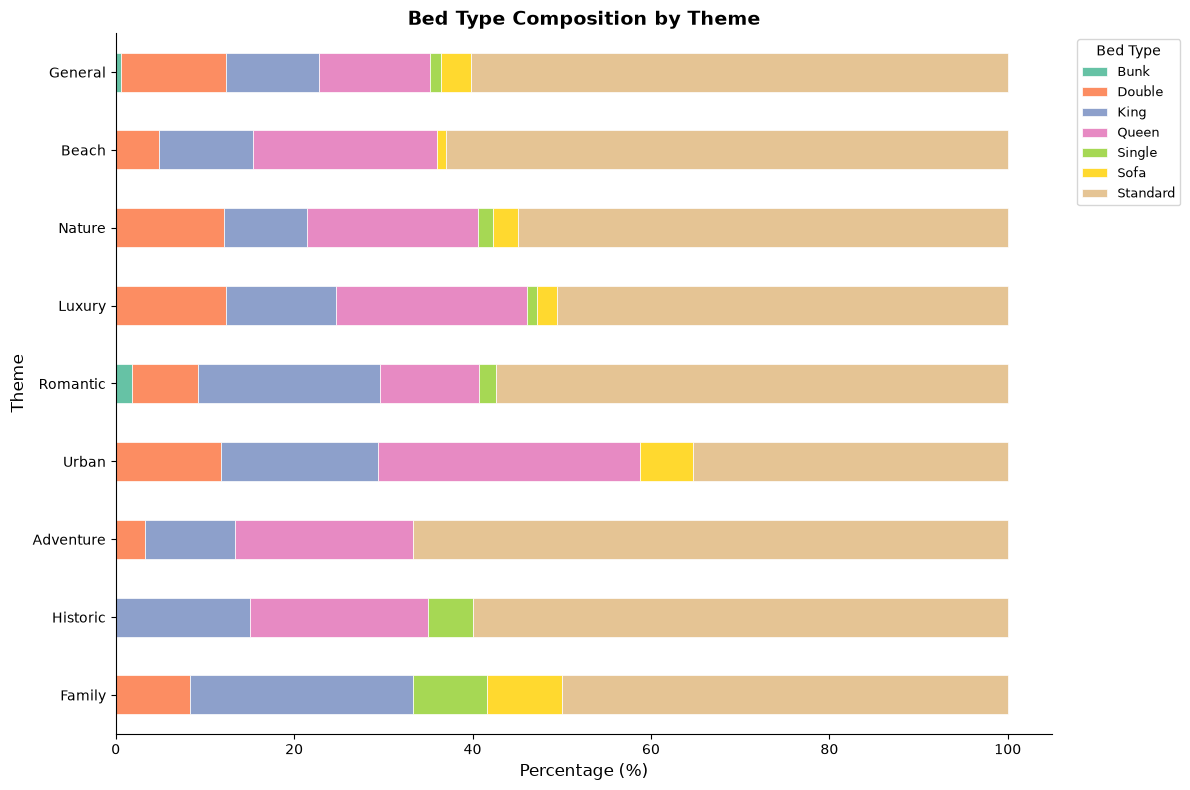

In [47]:
# Q: What's the bed-type breakdown within each theme?

bivariate_stacked_bar(df, "Theme", "Bed_Type", top_n_primary=9, top_n_secondary=7)

Cross-tab — Month × Theme (%)
Theme      Adventure      Beach    Family    General  Historic     Luxury      Nature   Romantic     Urban
Month                                                                                                     
August      0.000000  25.000000  0.000000  38.636364  0.000000  11.363636   25.000000   0.000000  0.000000
December    0.000000   0.000000  0.000000  50.000000  0.000000   0.000000    0.000000  50.000000  0.000000
January     0.000000   0.000000  0.000000   0.000000  0.000000   0.000000  100.000000   0.000000  0.000000
July        2.884615  24.038462  0.961538  33.653846  2.884615   6.730769   20.192308   4.807692  3.846154
June        3.671706  21.382289  1.511879  35.637149  2.159827   9.071274   17.278618   5.831533  3.455724
May         2.777778  22.619048  0.793651  32.539683  2.380952   6.746032   21.825397   5.555556  4.761905
November    7.692308   0.000000  0.000000  30.769231  7.692308   7.692308   30.769231  15.384615  0.000000
October

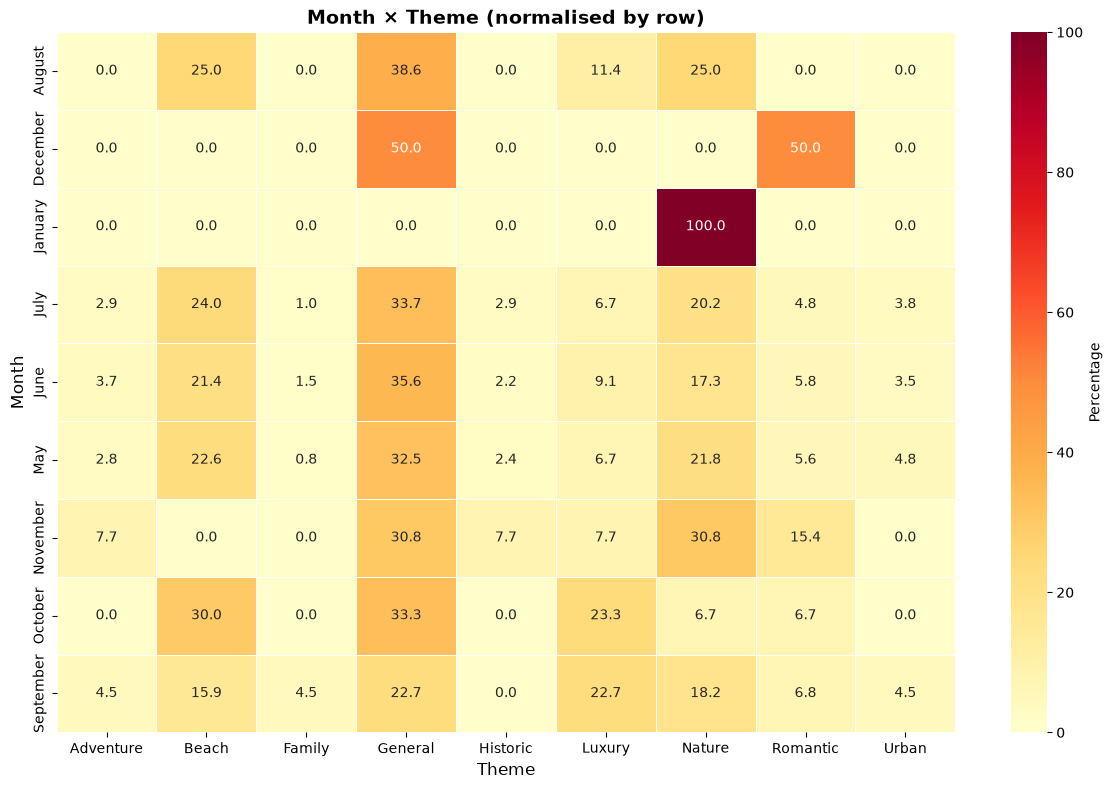

Theme,Adventure,Beach,Family,General,Historic,Luxury,Nature,Romantic,Urban
Month,,,,,,,,,
August,0.000000,25.000000,0.000000,38.636364,0.000000,11.363636,25.000000,0.000000,0.000000
December,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,50.000000,0.000000
January,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000
July,2.884615,24.038462,0.961538,33.653846,2.884615,6.730769,20.192308,4.807692,3.846154
June,3.671706,21.382289,1.511879,35.637149,2.159827,9.071274,17.278618,5.831533,3.455724
May,2.777778,22.619048,0.793651,32.539683,2.380952,6.746032,21.825397,5.555556,4.761905
November,7.692308,0.000000,0.000000,30.769231,7.692308,7.692308,30.769231,15.384615,0.000000
October,0.000000,30.000000,0.000000,33.333333,0.000000,23.333333,6.666667,6.666667,0.000000
September,4.545455,15.909091,4.545455,22.727273,0.000000,22.727273,18.181818,6.818182,4.545455


In [48]:
# Q: Do certain themes dominate specific months?  Are "Beach" listings
#    concentrated in June while "Nature" spreads more evenly?

categorical_crosstab_heatmap(df, "Month", "Theme", top_n_row=9, top_n_col=9)